# BITCOIN VOLATILITY PREDICTION

## IMPORTING PACKAGES

In [7]:
#access AWS through credentials
import boto3
import os
from io import StringIO, BytesIO


#data manipulation
import numpy as np
import pandas as pd

#plotting
import seaborn as sns
import matplotlib.pyplot as plt

#save models
import pickle
import joblib
#for lstm
from joblib import dump #save
from joblib import load #load

#build linear models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor
#compute evaluation metrics
from sklearn.metrics import make_scorer, root_mean_squared_error, mean_absolute_error, r2_score

#random forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import plot_tree

#xgboosting
from xgboost import XGBRegressor, plot_importance

#lightGBM
from lightgbm import LGBMRegressor

#SVR
from sklearn.svm import SVR

#metrics
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score

#LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from keras.optimizers import Adam, RMSprop
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasRegressor
import tensorflow as tf
from typing import Union, List, Tuple
from tensorflow import keras

#NGBoosting
from ngboost import NGBRegressor
from ngboost.distns import Normal
from ngboost.scores import MLE
from scipy.stats import norm
from sklearn.tree import DecisionTreeRegressor

#transformers
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from transformers import AutoModelForCausalLM, AutoTokenizer
# Import torch optimizer utilities
import torch.optim as optim

#PCA
from sklearn.decomposition import PCA

#Bayesian Optimization
import optuna

#Autocorrelation
from statsmodels.graphics.tsaplots import plot_acf

2026-02-25 21:29:37.554603: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-25 21:29:37.616402: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-25 21:29:39.200874: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
#path to models
path = "../models/"

## DEFINING USEFUL FUNCTION & CLASSES

- Compute accuracy metrics for a given model

In [9]:
def evaluate_model(model, X_val, y_val, model_name, scaler_y=None):
    """
    Evaluate a regression model, print metrics and return them as a dictionary.
    Works with both pandas Series/DataFrame or numpy arrays.
    """
    # Predict outcomes
    preds = model.predict(X_val)

    # If scaler_y is given, inverse transform both preds and y_val
    if scaler_y is not None:
        preds = scaler_y.inverse_transform(np.array(preds).reshape(-1, 1)).ravel()
        # handle either DataFrame/Series or ndarray
        if hasattr(y_val, "values"):
            y_val = y_val.values
        y_val = scaler_y.inverse_transform(np.array(y_val).reshape(-1, 1)).ravel()

    # Compute metrics
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)

    # Display metrics
    print(f"\n{model_name} Performance on Validation Set:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²  : {r2:.4f}")

    return {"RMSE": rmse, 
            "MAE": mae, 
            "R²": r2}

- Add a new row to the evalMetric table

In [10]:
def add_evaluation(metrics, model_name):
    """
    Add the evaluation metrics to the evalMetric table. If evalMetric does not
    exist, it will initilize it with the new row.
    
    Args:
        - metrics: results coming from func evaluate_model
        - model_name: name of the model (as it will appear in evalMetric)
        
    Returns:
        - evalMetric +1 rows
    """
    global evalMetrics  # Ensure it modifies the global DataFrame

    # Convert dictionary into DataFrame
    new_row = pd.DataFrame([metrics])  
    new_row.insert(0, "Model", model_name)  # Insert model name as the first column

    # If evalMetrics doesn't exist or is empty, initialize it with new_row
    if "evalMetrics" not in globals() or evalMetrics.empty:
        evalMetrics = new_row  # Direct assignment for the first row
    else:
        evalMetrics = pd.concat([evalMetrics, new_row], ignore_index=True)  # Append for subsequent rows
    
    # Return updated DataFrame
    return evalMetrics  

- Transforms time series features and labels into sequences suitable for training LSTM models.

In [11]:
def create_sequences_from_X_y(X_df, y_array, window_size=20):
    """
    Transforms time series features and labels into sequences suitable for training LSTM models.

    Parameters:
    -----------
    X_df : pd.DataFrame
        A DataFrame containing the input features, including a 'date' column which will be dropped.
    y_array : Union[pd.Series, np.ndarray]
        The target variable corresponding to X_df, either as a Series or NumPy array.
    window_size : int, default=20
        The number of past time steps to include in each input sequence.

    Returns:
    --------
    X_seq : np.ndarray
        3D array of shape (samples, window_size, features) for LSTM input.
    y_seq : np.ndarray
        1D array of target values aligned with each input sequence.
    """

    # Ensure the DataFrame index is sequential (0 to N-1)
    X_df = X_df.reset_index(drop=True)

    # Drop the 'date' column and convert remaining features to NumPy array
    X_values = X_df.drop(columns=['date']).values

    # Convert y_array to NumPy array and reset index if it's a Series
    if isinstance(y_array, pd.Series):
        y_array = y_array.reset_index(drop=True).values
    else:
        y_array = np.array(y_array)

    # Initialize lists to collect sequences
    X_seq, y_seq = [], []

    # Loop over the data to create sequences of length `window_size`
    for i in range(window_size, len(X_df)):
        # Get the window of features ending at position i (exclusive)
        X_seq.append(X_values[i-window_size:i])

        # Get the target value aligned with the current sequence
        y_seq.append(y_array[i])  # safe since y_array is now a NumPy array

    # Convert the lists to NumPy arrays and return
    return np.array(X_seq), np.array(y_seq)


- Plot NGBoosting predictions



In [12]:
def plot_ngboost_predictions(model, X_val, y_val, title="NGBoost Predictions with 95% CI",
    scaler_y=None, variance_scale=1.0):
    """
    Plot actual vs predicted values with 95% confidence intervals from NGBoost.
    """
    #Get predictive distribution
    dist = model.pred_dist(X_val)
    pred_mean = dist.loc
    pred_std = dist.scale * variance_scale  # ← ONLY CHANGE
    #Compute 95% confidence intervals
    ci_upper = pred_mean + 1.96 * pred_std
    ci_lower = pred_mean - 1.96 * pred_std
    #Inverse-transform if needed
    if scaler_y is not None:
        y_val = scaler_y.inverse_transform(np.array(y_val).reshape(-1, 1)).ravel()
        pred_mean = scaler_y.inverse_transform(pred_mean.reshape(-1, 1)).ravel()
        ci_upper = scaler_y.inverse_transform(ci_upper.reshape(-1, 1)).ravel()
        ci_lower = scaler_y.inverse_transform(ci_lower.reshape(-1, 1)).ravel()
    #Create time axis (index)
    x_axis = np.arange(len(y_val))
    #Plot
    plt.figure(figsize=(12, 6))
    plt.plot(x_axis, y_val, label="Actual", color="red", linewidth=1.5)
    plt.plot(x_axis, pred_mean, label="Predicted Mean", color="blue", linewidth=2)
    plt.fill_between(
        x_axis,
        ci_lower,
        ci_upper,
        color="blue",
        alpha=0.2,
        label="95% Confidence Interval"
    )
    #add aesthetic elements
    plt.title(title)
    plt.xlabel("Observation Index")
    plt.ylabel("Target Value")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


- Prediction interval coverage

In [13]:
def coverage(model, X_val, y_val, alpha=0.95, scaler_y=None):
    """
    Compute prediction interval coverage for NGBoost.
    
    Parameters
    ----------
    model : trained NGBoost model
    X : features
    y_true : true target values
    alpha : confidence level (default 0.95)
    scaler_y : optional scaler used on y

    Returns
    -------
    coverage : empirical coverage rate
    """
    # Get predictive distribution
    dist = model.pred_dist(X_val)

    mu = dist.loc
    sigma = dist.scale

    # Z-score for the given confidence level
    z = norm.ppf(0.5 + alpha / 2)

    lower = mu - z * sigma
    upper = mu + z * sigma

    # Inverse transform if needed
    if scaler_y is not None:
        mu = scaler_y.inverse_transform(mu.reshape(-1, 1)).ravel()
        lower = scaler_y.inverse_transform(lower.reshape(-1, 1)).ravel()
        upper = scaler_y.inverse_transform(upper.reshape(-1, 1)).ravel()

        if hasattr(y_val, "values"):
            y_val = y_val.values
        y_val = scaler_y.inverse_transform(
            np.array(y_val).reshape(-1, 1)
        ).ravel()

    # Coverage computation
    coverage = np.mean((y_val >= lower) & (y_val <= upper))

    return coverage


- Negative Log-Likelihood

In [14]:
def nll_score(model, X_val, y_val, scaler_y=None):
    dist = model.pred_dist(X_val)

    mu = dist.loc
    sigma = dist.scale

    if scaler_y is not None:
        mu = scaler_y.inverse_transform(mu.reshape(-1, 1)).ravel()
        sigma = scaler_y.scale_ * sigma  
        if hasattr(y_val, "values"):
            y_val = y_val.values
        y_val = scaler_y.inverse_transform(
            np.array(y_val).reshape(-1, 1)
        ).ravel()

    nll = (
        0.5 * np.log(2 * np.pi)
        + np.log(sigma)
        + 0.5 * ((y_val - mu) / sigma) ** 2
    )

    return np.mean(nll)


- CRPS

In [15]:
def crps_score(model, X_val, y_val, scaler_y=None):
    
    dist = model.pred_dist(X_val)

    mu = dist.loc
    sigma = dist.scale

    if scaler_y is not None:
        mu = scaler_y.inverse_transform(mu.reshape(-1, 1)).ravel()
        sigma = scaler_y.scale_ * sigma
        if hasattr(y_val, "values"):
            y_val = y_val.values
        y_val = scaler_y.inverse_transform(
            np.array(y_val).reshape(-1, 1)
        ).ravel()

    z = (y_val - mu) / sigma

    crps = sigma * (
        z * (2 * norm.cdf(z) - 1)
        + 2 * norm.pdf(z)
        - 1 / np.sqrt(np.pi)
    )
    return np.mean(crps)

- Transforms time series features and labels into sequences suitable for training Transformers

In [16]:
def create_transformer_sequences(X_df, y_array, window_size=20, forecast_horizon=1):
    """
    Prepares multivariate time series data for a Transformer model.
    
    Parameters
    ----------
    X_df : pd.DataFrame
        Input features, including a 'date' column which will be dropped.
    y_array : pd.Series or np.ndarray
        Target variable.
    window_size : int
        Number of past timesteps for the input sequence.
    forecast_horizon : int
        Number of future timesteps to predict (default 1 for 1-step ahead).
    
    Returns
    -------
    X_seq : np.ndarray
        3D array of shape (samples, window_size, features)
    y_seq : np.ndarray
        2D array of shape (samples, forecast_horizon)
    """
    
    # Reset index
    X_df = X_df.reset_index(drop=True)
    
    # Drop 'date' and convert to NumPy
    X_values = X_df.drop(columns=['date']).values
    
    # Convert y_array to NumPy
    y_array = np.array(y_array) if not isinstance(y_array, np.ndarray) else y_array
    
    X_seq, y_seq = [], []
    
    for i in range(window_size, len(X_df) - forecast_horizon + 1):
        X_seq.append(X_values[i-window_size:i])
        y_seq.append(y_array[i:i+forecast_horizon])
    
    return np.array(X_seq), np.array(y_seq)


- Define time-series dataset class wokring with PyTorch dataloader

In [17]:
# Define time series Dataset class
class TimeSeriesDataset(Dataset):
    #initialize dataset with feature matrix X and target vector y
    def __init__(self, X, y):
        #convert X (nupmy array) to a pytorch tensor (of floats) and store it
        self.X = torch.tensor(X, dtype=torch.float32)
        #convert y (nupmy array) to a pytorch tensor and store it
        self.y = torch.tensor(y, dtype=torch.float32)
    #return total number of dataset's samples 
    def __len__(self):
        return len(self.X)
    #return one sample (features & target) at the requested index
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

- Define a transformer based NN for time series forecasting with positional econding

In [18]:
class TimeSeriesTransformer(nn.Module):
    # Initialize the Transformer with standard hyperparameters
    def __init__(
        self,
        n_features,       # number of input features per time step
        d_model=64,       # dimension of the model embeddings
        n_heads=4,        # number of attention heads
        n_layers=2,       # number of transformer encoder layers
        dropout=0.1       # dropout rate for regularization
    ):
        # Call the parent constructor to initialize nn.Module
        super().__init__()

        # Linear layer to project input features into d_model dimension
        self.input_projection = nn.Linear(n_features, d_model)
        # Learnable positional encoding to inject sequence order information
        self.positional_encoding = nn.Parameter(torch.zeros(1, 20, d_model))

        # Define a single Transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,   # embedding dimension
            nhead=n_heads,     # number of attention heads
            dropout=dropout,   # dropout rate
            batch_first=True   # input shape is (batch, seq_len, features)
        )

        # Stack multiple encoder layers to create the full Transformer
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        # Linear layer to map Transformer output to a single target prediction
        self.output_layer = nn.Linear(d_model, 1)

    # Define forward pass through the model
    def forward(self, x, return_hidden = False ):
        """
        x: input tensor of shape (batch, window, features)
        """
        # Project input features to d_model dimension
        x = self.input_projection(x)
        # Add positional encoding to the input embeddings
        x = x + self.positional_encoding[:, :x.size(1), :]
        # Pass through the Transformer encoder
        x = self.transformer(x)

        #stroe last time-step representation (penultimate layer=
        hidden_rep = x[:,-1,:]
        # Take the last time step's output and map to final prediction
        out = self.output_layer(hidden_rep)
        
        # Return the predicted value and hidder rep (if return_hidden = True)
        if return_hidden:
            return out, hidden_rep
        #otherwise return just predictions
        return out


- Apply a random masking across a full batch

In [19]:
# Define a function that applies random masking across a full batch
def apply_mask_batch(x, mask_ratio=0.2):
    """
    x: tensor of shape (batch_size, window_size, n_features)
    Returns: 
        masked -> same tensor but with some values set to zero
        (b_idx, s_idx, f_idx) -> indices of the masked elements
    """
    #Create a copy so original input isn't modified
    masked = x.clone()
    #Unpack tensor dimensions: batch size, sequence length, number of features
    batch_size, seq_len, n_features = x.shape
    #Compute total number of values across entire batch
    total_elements = batch_size * seq_len * n_features
    #Compute how many elements should be masked
    num_mask = int(mask_ratio * total_elements)
    
    #Generate random shuffled indices from 0 to total_elements-1 and select first num_mask
    flat_idx = torch.randperm(total_elements)[:num_mask]
    #Convert flat indices back into batch indices
    b_idx = flat_idx // (seq_len * n_features)
    #Convert remaining part into sequence indices
    s_idx = (flat_idx % (seq_len * n_features)) // n_features

    #Convert final remainder into feature indices
    f_idx = flat_idx % n_features
    #Set selected batch-sequence-feature locations to zero (masking)
    masked[b_idx, s_idx, f_idx] = 0.0
    #Return masked tensor and tuple of indices to compute reconstruction loss later
    return masked, (b_idx, s_idx, f_idx)


- Define a transformer model that re-construct masked time-series data

In [20]:
# Define a Transformer model that reconstructs masked time-series data
class MaskedTimeSeriesTransformer(nn.Module):

    # Constructor: define model architecture
    def __init__(self, feature_dim, embed_dim=32, num_heads=2, num_layers=2):
        
        # Initialize parent PyTorch nn.Module
        super().__init__()
        
        # Linear layer to project raw features into transformer embedding space
        self.input_proj = nn.Linear(feature_dim, embed_dim)
        #Input: feature_dim (how many features)
        #Output: embed_dim  (n-dimensional representation per timestep)
        
        # Define a single Transformer Encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, #embedding size
            nhead=num_heads, #number of attention heads
            batch_first=True #input is: batch, seq_len, feature
        )

        # Stack multiple encoder layers to build a deeper transformer
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers #number of layers
        )

        # Linear layer to map embeddings back to original feature space
        self.output_head = nn.Linear(embed_dim, feature_dim)
        # Input: embed_dim (transformer output)
        # Output: feature_dim (original variables)


    # Forward pass: defines data flow through the network
    def forward(self, x):
        
        #project raw features into embedding space
        z = self.input_proj(x)
        # Input shape:  (batch, seq_len, feature_dim)
        # Output shape: (batch, seq_len, embed_dim)

        #pass embeddings through transformer encoder
        h = self.transformer(z)
        #output shape: (batch, seq_len, embed_dim)

        #reconstruct the original masked time series
        out = self.output_head(h)
        #output shape: (batch, seq_len, feature_dim)

        #return
        return out, h
        #out:reconstruction (used for training loss)
        #h: hidden embeddings (used later a market state features)


- Train a transformer using masked reconstruction on batched ts data

In [21]:
def train_model_batch(model, loader, epochs=20, lr=1e-3, mask_ratio=0.2):
    #define MSE as the reconstruction loss
    criterion = nn.MSELoss()
    #use adam optimizer to update model params
    optimizer = optim.Adam(model.parameters(), lr=lr)

    #loop over training epochs
    for epoch in range(epochs):
        #set training mode
        model.train()
        #reset loss accumulator
        running_loss = 0.0
        #iterate over mini-batches from DataLoader
        for batch in loader:
            #extract the input tensor from the batch
            x = batch[0]  # shape: (batch_size, window_size, n_features)
            #apply random masking & retrive indixes of masked positions
            masked, (b_idx, s_idx, f_idx) = apply_mask_batch(x, mask_ratio)
            #forward pass -> reconstruct masked time-series
            recon, _ = model(masked)
            #compute loss only on the masked (i.e hidden) elements
            loss = criterion(recon[b_idx, s_idx, f_idx], x[b_idx, s_idx, f_idx])

            #reset previous gradient
            optimizer.zero_grad()
            #backpropagate reconstruction error
            loss.backward()
            #update model params
            optimizer.step()

            #sum up batch loss scaled by batch size
            running_loss += loss.item() * x.size(0)
            
        #compute mean epoch loss over entire dataset
        epoch_loss = running_loss / len(loader.dataset)
        #print progesses
        print(f"Epoch {epoch+1}/{epochs}  Loss: {epoch_loss:.6f}")

- Defines a function to extract latent embeddings from a trained transformer.

In [22]:
def extract_embeddings(model, data):
    #set evaluation mode
    model.eval()
    #disable gradient tracking (reduce memory)
    with torch.no_grad():
        #run the data trhough the model and get the hidden transformer states
        _, hidden = model(data)
        #collapse the time dimensions by avg each seq representation
        embeddings = hidden.mean(dim=1)  # mean pooling across time
    #retunr the final embedding matrix
    return embeddings

## LOADING THE DATASES

The dataset has been already pre-processed, cleaned and split (60% train, 20% validation, 20% testing).  
  
Moreover, features have already been scaled. In details, All numeric features and the target variable were standardized using StandardScaler, fitted only on the training data, to ensure consistency and prevent data leakage.  

As such, here it is enough just to load all the 6 datasets.
  
Note. To explore the cleaning procedure, take a look at the files "02_data_cleaning.ipynb" and "feature_engineering.ipynb".

Let's load the datasets from the AWS bucket.

In [23]:
# Use the AWS Access and Secret keys if not available
s3 = boto3.client('s3')

Define the credentials to access the bucket in AWS as environmental variables. Note this will last only during the session.

In [ ]:
# Set AWS credentials as environment variables
os.environ['AWS_ACCESS_KEY_ID'] = " " #add access key
os.environ['AWS_SECRET_ACCESS_KEY'] = " " #add secret access key
os.environ['AWS_DEFAULT_REGION'] = " "  #select region

Define the S3 bucket and list the files in it.

In [ ]:
# Initialize S3 client
s3 = boto3.client('s3')

# Define the S3 bucket name
bucket_name = ' ' #set bucket name

# List objects in the bucket
response = s3.list_objects_v2(Bucket=bucket_name)

# Check if the bucket has objects
if 'Contents' in response:
    for item in response['Contents']:
        print(item['Key'])
else:
    print("No files found in the bucket")


crypto_volatility21_fe.csv
crypto_volatility21_fe.parquet
crypto_volatility30_fe.csv
crypto_volatility30_fe.parquet
crypto_volatility_clean.csv
crypto_volatility_clean.parquet
crypto_volatility_fe5.csv
crypto_volatility_fe5.parquet
crypto_volatility_raw.csv
crypto_volatility_raw.parquet
scaled_data/X_tr_scal.csv
scaled_data/X_tr_scal21.csv
scaled_data/X_tr_scal30.csv
scaled_data/X_tr_scal_ewm.csv
scaled_data/X_tr_scal_ewm_noStd.csv
scaled_data/X_tt_scal.csv
scaled_data/X_tt_scal21.csv
scaled_data/X_tt_scal30.csv
scaled_data/X_tt_scal_ewm.csv
scaled_data/X_tt_scal_ewm_noStd.csv
scaled_data/X_val_scal.csv
scaled_data/X_val_scal21.csv
scaled_data/X_val_scal30.csv
scaled_data/X_val_scal_ewm.csv
scaled_data/X_val_scal_ewm_noStd.csv
scaled_data/y_tr_scal.csv
scaled_data/y_tr_scal21.csv
scaled_data/y_tr_scal30.csv
scaled_data/y_tr_scal_ewm.csv
scaled_data/y_tt_scal.csv
scaled_data/y_tt_scal21.csv
scaled_data/y_tt_scal30.csv
scaled_data/y_tt_scal_ewm.csv
scaled_data/y_val_scal.csv
scaled_data/

Load the needed dataset. These are:  
  
- scaled_data/X_tr_scal_ewm.csv
- scaled_data/X_tt_scal_ewm.csv
- scaled_data/X_val_scal_ewm.csv
- scaled_data/y_tr_scal_ewm.csv
- scaled_data/y_tt_scal_ewm.csv
- scaled_data/y_val_scal_ewm.csv
- unscaled_data/X_tr_ewm.csv
- unscaled_data/X_tt_ewm.csv
- unscaled_data/X_val_ewm.csv
- unscaled_data/y_tr_ewm.csv
- unscaled_data/y_tt_ewm.csv
- unscaled_data/y_val_ewm.csv  
  
Along with the y-scaler (scaler_y.pkl)

In [26]:
# Initialize boto3 client
s3 = boto3.client('s3')

In [27]:
# dictionary to store all the dataframes (both scaled and not)
dataframes = {}

In [28]:
# S3 bucket and file keys for scaled data
file_keys_scaled = [
    'scaled_data/X_tr_scal_ewm.csv', 
    'scaled_data/X_tt_scal_ewm.csv',
    'scaled_data/X_val_scal_ewm.csv',
    'scaled_data/y_tr_scal_ewm.csv',
    'scaled_data/y_tt_scal_ewm.csv',
    'scaled_data/y_val_scal_ewm.csv'
]

# Loop and assign each df to a variable and to the dictionary
for key in file_keys_scaled:
    response = s3.get_object(Bucket=bucket_name, Key=key)
    csv_content = response['Body'].read().decode('utf-8')

    df_name = key.removeprefix('scaled_data/').removesuffix('_ewm.csv') #name the df
    df = pd.read_csv(StringIO(csv_content), index_col=0)#transform csv into a pd df

    # Assign to dictionary
    dataframes[df_name] = df

    # Assign to a variable in global scope
    globals()[df_name] = df

In [29]:
# S3 bucket and file keys for unscaled data
file_keys = [
    'unscaled_data/X_tr_ewm.csv', 
    'unscaled_data/X_tt_ewm.csv',
    'unscaled_data/X_val_ewm.csv',
    'unscaled_data/y_tr_ewm.csv',
    'unscaled_data/y_tt_ewm.csv',
    'unscaled_data/y_val_ewm.csv',
]

# Loop and assign each df to a variable and to the dictionary
for key in file_keys:
    response = s3.get_object(Bucket=bucket_name, Key=key)
    csv_content = response['Body'].read().decode('utf-8')

    df_name = key.removeprefix('unscaled_data/').removesuffix('_ewm.csv') #name the df
    df = pd.read_csv(StringIO(csv_content), index_col=0)#transform csv into a pd df

    # Assign to dictionary
    dataframes[df_name] = df

    # Assign to a variable in global scope
    globals()[df_name] = df

In [30]:
#check df has been properly loaded
print(X_tr_scal)

            date     close    volume     trend  fg_index  cluster  log_return  \
0     2018-02-07 -0.712976  0.168652  1.116642 -0.367605        0   -0.199027   
1     2018-02-08 -0.702790 -1.540343  0.657685 -0.632067        0    0.587014   
2     2018-02-09 -0.653246 -0.993489  0.313466 -0.014990        0    2.749266   
3     2018-02-10 -0.661501 -0.160041 -0.088122  0.425780        0   -0.463748   
4     2018-02-11 -0.687382 -0.285679 -0.260231 -0.587990        4   -1.458020   
...          ...       ...       ...       ...       ...      ...         ...   
1577  2022-06-03  0.503800 -0.024896 -0.317600 -1.513607        5   -0.656318   
1578  2022-06-04  0.512820 -0.845393 -0.547079 -1.337299        5    0.116901   
1579  2022-06-05  0.515857 -0.916859 -0.604449 -1.513607        5    0.024292   
1580  2022-06-06  0.595901  0.401062 -0.317600 -1.381376        5    1.179715   
1581  2022-06-07  0.582260  1.607676 -0.145491 -1.293222        5   -0.223354   

      hl_spread  momentum_3

In [31]:
#check df has been properly loaded
print(X_tr)
print(y_tr.head())

            date     close         volume  trend  fg_index  cluster  \
0     2018-02-07   7599.00   60778.460497     49      36.0        0   
1     2018-02-08   7784.02    1521.537318     41      30.0        0   
2     2018-02-09   8683.92   20482.910825     35      44.0        0   
3     2018-02-10   8533.98   49381.512653     28      54.0        0   
4     2018-02-11   8063.88   45025.187952     25      31.0        4   
...          ...       ...            ...    ...       ...      ...   
1577  2022-06-03  29700.21   54067.447270     24      10.0        5   
1578  2022-06-04  29864.04   25617.901130     20      14.0        5   
1579  2022-06-05  29919.21   23139.928100     19      10.0        5   
1580  2022-06-06  31373.10   68836.924560     24      13.0        5   
1581  2022-06-07  31125.33  110674.516580     27      15.0        5   

      log_return  hl_spread  momentum_3    vol_change  rolling_std_5  
0      -0.006969    1325.99     -585.81 -39423.039810       0.108378  
1    

Finally, let's load the Y's scaler to reverse prediction during models' evaluation.

In [32]:
# load the scaler from S3
#define the scaler
scaler_key = "scaler_y.pkl"
#load the scaler
scaler_response = s3.get_object(Bucket=bucket_name, Key=scaler_key)
scaler_y = joblib.load(BytesIO(scaler_response['Body'].read())) #BytesIO treat a binary output as a file

SHIFT VOLATILITY FOR T+1 PREDICTIONS

In [33]:
def make_forecast_target(X: pd.DataFrame, y: pd.Series):
    """
    Align X(t) -> y(t+1)
    """
    y_shifted = y.shift(-1)

    # drop last row (no t+1 target)
    X_aligned = X.iloc[:-1].copy()
    y_aligned = y_shifted.iloc[:-1].copy()

    return X_aligned, y_aligned


# Shift targets (unscaled)
X_tr, y_tr = make_forecast_target(X_tr, y_tr)
X_val, y_val = make_forecast_target(X_val, y_val)
X_tt, y_tt = make_forecast_target(X_tt, y_tt)
# Shift targets (scaled)
X_tr_scal, y_tr_scal = make_forecast_target(X_tr_scal, y_tr_scal)
X_val_scal, y_val_scal = make_forecast_target(X_val_scal, y_val_scal)
X_tt_scal, y_tt_scal = make_forecast_target(X_tt_scal, y_tt_scal)

#sanity checks
assert len(X_tr) == len(y_tr)
assert X_tr.index.equals(y_tr.index)

print("First X row date:", X_tr.index[0])
print("First y row date (t+1):", y_tr.index[0])

print(X_tr.head(3))
print(y_tr.head(3))


First X row date: 0
First y row date (t+1): 0
         date    close        volume  trend  fg_index  cluster  log_return  \
0  2018-02-07  7599.00  60778.460497     49      36.0        0   -0.006969   
1  2018-02-08  7784.02   1521.537318     41      30.0        0    0.024056   
2  2018-02-09  8683.92  20482.910825     35      44.0        0    0.109400   

   hl_spread  momentum_3    vol_change  rolling_std_5  
0    1325.99     -585.81 -39423.039810       0.108378  
1     271.91      844.03 -59256.923179       0.106621  
2     948.10     1031.78  18961.373507       0.110290  
   volatility
0    0.047295
1    0.058076
2    0.063501


## MODEL SELECTION

### MODELING PROCEDURE

Through this analysis, several different models are implemented in order to choose a final top-performing model. In details, the procedure will go as follows:  
  
- Choose a set of models to implement. This choice is flexible, and additional models can be introduced at any stage.  
- Perform Light tuning and fit (with TimeSeriesSplit validation to keep temporal-ordering during validation) each model on the training dataset (X_scal_tr and y_scal_tr). Light-tuning uses a narrow hyperparameter grid to save computational resources and time.
- Evaluate each model on the validation set (X-val_scal and y_val_scal) using consistent scoring metrics (named scoring).
- Select the top 2-3 performing models based on evaluation metrics. 
- Fine-tune the top performing models on the training set. This is done with a broader hyper-parameters grid.
- Re-evaluate the top models on the validation set. 
- Choose the overall top-performing model. This is the “champion” model.
- Evaluate this model on the unseen dataset, i.e the testing set (X_scal_tt, y_scal_tt), using the same metrics as before.
- If performance is satisfactory, prepare the model for deployment (including discussion of limitations and interpretability). If not, revisit feature engineering or model selection.
   
Feature importance (or SHAP) may be explored on the top-performing models to support interpretability.  
  
Finally, all model scores will be collected in a summary table (evalMetrics) for comparison).  
  
Note. All random seeds are fixed for reproducibility.

### MODELS' SET

For the analysis' purposes, the models taken into consideration are:  
  
- Linear Regression
- Ridge/Lasso regression
- Random Forest
- XGboost
- LightGBM
- Support Vector Regression (SVR)
- Long-short term memory (LSTM)  
  
As aforementioned, only the top 2-3 performing models will receive more in-depth tuning.

### EVALUATION METRICS & BASELINE MODEL

Since this is a regression task, the evaluation metrics considered are: 

- **Root mean Squared Error (RMSE)**: measures the average magnitude of the errors. It is scale-independent, making it suitable for model comparisons.
- **Mean Absolute Error (MAE)**: captures the mean absolute difference between predictions and actuals values It shares the same unit as the target.
- **R-squared**: shows the proportion of target's variance explained by the model.

The main metric will be RMSE since it *a)* penalized larger errors more heavily; and *b)* is commonly used in models sensitive to significant prediction errors. Therefore, the model having the lowest RMSE will be considered the most-efficient.

Nevertheless, all three metrics will always be assessed together. Examining their relationships can reveal potential issues. More in details:

- **RMSE vs R-squared**: conflicting signals may point out to the need to inspect residuals and re-evaluate the feature set or model complexity.
- **RMSE vs MAE**: RMSE is always >= MAE. The larger difference, the greater the variance in individual erros across the sample.

Let's define all the metrics, wrap them up in the 'scoring' dictionary and display the target's range and standard deviation.

In [34]:
# Define custom scorers
#Note: on some greater_is_better=False is added since for those the lower the value, the best it is (whithout that, Gridsearch will try to 
#maximize those, leading to the opposite).
#rmse
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)
#MAE
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
#r-sqaured
r2_scorer = make_scorer(r2_score)

#include them into a dictionary
scoring = {
    'RMSE': rmse_scorer,
    'MAE': mae_scorer,
    'R2': r2_scorer
}

In [35]:
#show the target variable ranges and std to interpret MAE easily
print("")
print("Bitcoin Volatility range:")
print(f"min: {y_tr["volatility"].min():.3f} - max: {y_tr["volatility"].max():.3f}")
print("")
print("Bitcoin Volatility standard deviation:")
print(f"{y_tr["volatility"].std():.3f}")


Bitcoin Volatility range:
min: 0.005 - max: 0.273

Bitcoin Volatility standard deviation:
0.020


As a general guideline, a MAE > target's std points to the model prediction error exceeding the natural data variability. This suggests the model could likely be improved. 

Neverthless, a more reliable bencharmk is to compare the accuracy measures against those of a baseline model to really assess its predictive abilities. In this case, the baseline model is a simple mean predictor. 

Let's compute its performances and include them to the evaluation table.

In [36]:
#compute the mean of the training target
mean_value = y_tr.mean()
#Create predictions for the val set
mean_pred_val = np.full_like(y_val, mean_value)
#compute evaluation metrics
mean_mae = mean_absolute_error(y_val, mean_pred_val)
mean_rmse = np.sqrt(mean_squared_error(y_val, mean_pred_val))
mean_r2 = r2_score(y_val, mean_pred_val)
#store them into a dictionary
meanval = {"RMSE": mean_rmse, "MAE": mean_mae, "R²": mean_r2}
#add evaluations to the evalMetrics table
add_evaluation(meanval, "Baseline model: Mean")

,Model,RMSE,MAE,R²
0,Baseline model: Mean,0.017954,0.015728,-0.660527


These values are the baseline metrics, serving as a threshold for comparison across models. If a model performs worse than these, it highlights that simply predicting the training data's average would be a better estimator. In other words, the model fails to capture meaningful patterns beyond the average behavior of the series.

Therefore, any model achieving lower RMSE and MAE and higher R-squared is providing genuine predictive value.

### MODEL VALIDATION

Validating the model is crucial to ensure results fairness and to assess model performance. In this analysis, two complementary validation techniques are employed:

- **Cross-validation**: the model is trained and tested on different data folds in each iteration. Specifically, the training set is split into n-training folds to build the model, and 1 validation fold to evaluate it. Due to the time-series nature of data, the folds are created while preserving their chronological order.
- **Held-out validation set**: a portion of the dataset is kept aside and used only for final validation after the model is trained on the entire training set. When finally testing the model, the model is then trained on the full (training + validation) set.

Together, these methods ensure unbiased results and prevents information leakage from the validation set. 
 
Note. Cross-validation is performed with 4 folds for most models, except for LSTM where 3 folds are used.

In [37]:
#define the number of splits (4) during cross validation
tscv = TimeSeriesSplit(n_splits=4)

### LINEAR REGRESSION

The simpliest model to implement is a linear regression. It does not require hyperparameters tuning and often yields reasonable results. Moreover, it relies on a limited set of assumptions: 
  
- Linearity: assumes a linear relatiosnhip between the predictors and the target.
- Independence: data points are independent. This is true for the df, as data are measured over different days.
- Absence of multicollinearity: tested and tackled during feature engineering.
- No extreme outliers: there are some outliers. Nevertheless, they are not that severe and including them helps in dealing with uncommon situations too.
  
Let's implement the model.

In [38]:
#define the model
linreg = LinearRegression()
#fit the model on training set
linreg.fit(X_tr_scal.drop(columns=['date']), y_tr_scal)
#evaluate the model
linval = evaluate_model(linreg, X_val_scal.drop(columns=['date']), y_val_scal, 'Linear Regression', scaler_y=scaler_y)


Linear Regression Performance on Validation Set:
RMSE: 0.0225
MAE: 0.0171
R²  : -1.3520


Let's add the evaluations to the table.

In [39]:
#add evaluations to the evalMetrics table
add_evaluation(linval, "Linear Regression")

,Model,RMSE,MAE,R²
0,Baseline model: Mean,0.017954,0.015728,-0.660527
1,Linear Regression,0.022542,0.017061,-1.352012


### HUBER REGRESSION - outliers' role

The Huber regression reduces the errors' contribution of data having large residuals by introducing a threshold. If the residual is smaller than the threshold, it employs MSE; if not, it opts for a function having a smaller output than a MSE. This makes Huber particularly effective in dealing with datasets having noise, heavy tails or influential outliers.

Let's implement and assess a Huber regression.

**Note**. Since this is meant to be a quick sanity check, the threshold will not be tuned.

In [40]:
#define the Huber model
hubreg = HuberRegressor()
#fit the huber model on training set
hubreg.fit(X_tr_scal.drop(columns=['date']), y_tr_scal.squeeze())
#Note. squeeze() flattes a pandas df into a series (as Huber expects y to be a 1D array)
#evaluate the model
hubval = evaluate_model(hubreg, X_val_scal.drop(columns=['date']), y_val_scal, 'Huber Regression', scaler_y=scaler_y)


Huber Regression Performance on Validation Set:
RMSE: 0.0162
MAE: 0.0122
R²  : -0.2100


In [41]:
#add evaluations to the evalMetrics table
add_evaluation(hubval, "Huber Regression")

,Model,RMSE,MAE,R²
0,Baseline model: Mean,0.017954,0.015728,-0.660527
1,Linear Regression,0.022542,0.017061,-1.352012
2,Huber Regression,0.016168,0.012216,-0.209968


**Note**. Huber regression could serve as a more robust baseline model, adding a *"sanity check"* on outliers' role.

### LASSO REGRESSION - feature selection

LASSO is a linear regressio technique that incorporates L1 regularization to prevent overfitting and perform feature selection. It does so by shrinking some feature's coeffcients to (or near) 0, if they are deem weak or redundant.

How aggressively LASSO shrinks parameters depens on lambda, the model's only tunable parameter. If it is too large, it can cause overfitting, while a too-small lambda may lead to overfitting. 

In this analysis, lambda will be tested over the range 10^-3 and 10^1. 

In [42]:
#define alpha's range
alphas = np.logspace(-3, 1, 10)  # 10 values from 10⁻³ to 10¹
#initialize a list for coefs
lasso_coefs = []
#show the alphas
print(alphas)

[1.00000000e-03 2.78255940e-03 7.74263683e-03 2.15443469e-02
 5.99484250e-02 1.66810054e-01 4.64158883e-01 1.29154967e+00
 3.59381366e+00 1.00000000e+01]


In [43]:
# Fit LASSO for each alpha
for alpha in alphas:
    lasso = Lasso(alpha=alpha, fit_intercept=True, max_iter=5000)  # Increase iterations if needed
    lasso.fit(X_tr_scal.drop(columns=['date']), y_tr_scal)
    lasso_coefs.append(lasso.coef_)

In [44]:
# Convert to DataFrame for better readability
lasso_coefs = np.array(lasso_coefs)
# get feature names and Convert to list if needed
feature_names = X_tr_scal.columns.tolist()
#drop date column
feature_names.remove('date')

Let's display the coefficient shrinkage plot to understand variables behavior.

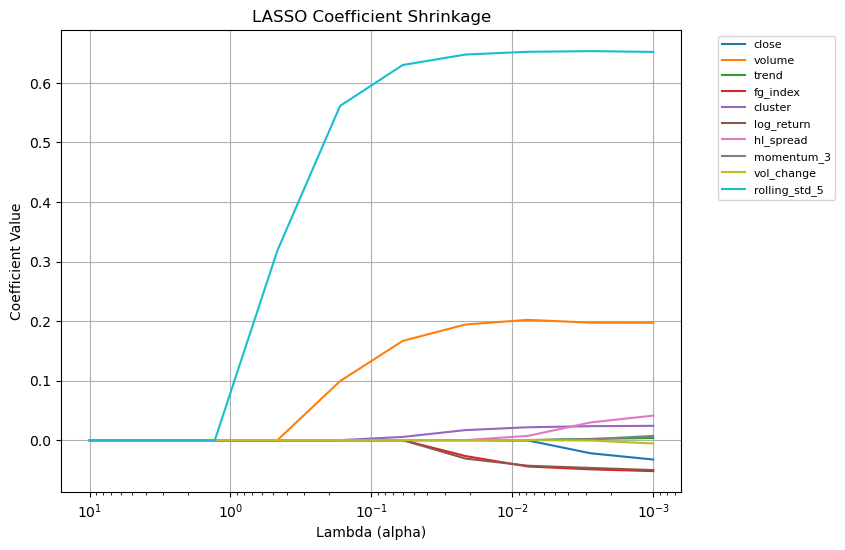

In [45]:
# Plot coefficient shrinkage
plt.figure(figsize=(8,6))
for i, feature in enumerate(feature_names):
    plt.plot(alphas, lasso_coefs[:, i], label=feature)

plt.xscale("log")  # Log scale for lambda
plt.gca().invert_xaxis()  # Reverse x-axis (large lambda → stronger shrinkage)
plt.xlabel("Lambda (alpha)")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Shrinkage")
plt.legend(loc="best", fontsize=8, bbox_to_anchor=(1.05, 1))  # Place legend outside
plt.grid()
plt.show()

In [46]:
# Track the best model info
best_model = None
best_alpha = None
best_rmse = float('inf')  # Lower is better
best_r2 = float('-inf')   # Higher is better

# Loop through alphas
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_tr_scal.drop(columns=['date']), y_tr_scal)
    
    # Evaluate model
    results = evaluate_model(lasso, X_val_scal.drop(columns=['date']), y_val_scal, f"Lasso (alpha={alpha:.4f})")
    
    # Check if current model is better
    if results["RMSE"] < best_rmse:
        best_rmse = results["RMSE"]
        best_r2 = results["R²"]
        best_model = lasso
        best_alpha = alpha
    elif results["RMSE"] == best_rmse and results["R²"] > best_r2:
        # Use R² as a tie-breaker
        best_r2 = results["R²"]
        best_model = lasso
        best_alpha = alpha

#save the best model
lasso_model = best_model
        
# Summary
print(f"\n Best model: Lasso (lambda={best_alpha})")
print(f"    RMSE: {best_rmse:.4f}")
print(f"    R²:   {best_r2:.4f}")



Lasso (alpha=0.0010) Performance on Validation Set:
RMSE: 1.0639
MAE: 0.8055
R²  : -1.3558

Lasso (alpha=0.0028) Performance on Validation Set:
RMSE: 1.0660
MAE: 0.8074
R²  : -1.3652

Lasso (alpha=0.0077) Performance on Validation Set:
RMSE: 1.0906
MAE: 0.8279
R²  : -1.4754

Lasso (alpha=0.0215) Performance on Validation Set:
RMSE: 1.0594
MAE: 0.8123
R²  : -1.3359

Lasso (alpha=0.0599) Performance on Validation Set:
RMSE: 0.9542
MAE: 0.7547
R²  : -0.8950

Lasso (alpha=0.1668) Performance on Validation Set:
RMSE: 0.7232
MAE: 0.6220
R²  : -0.0884

Lasso (alpha=0.4642) Performance on Validation Set:
RMSE: 0.6614
MAE: 0.5719
R²  : 0.0894

Lasso (alpha=1.2915) Performance on Validation Set:
RMSE: 0.8932
MAE: 0.7825
R²  : -0.6605

Lasso (alpha=3.5938) Performance on Validation Set:
RMSE: 0.8932
MAE: 0.7825
R²  : -0.6605

Lasso (alpha=10.0000) Performance on Validation Set:
RMSE: 0.8932
MAE: 0.7825
R²  : -0.6605

 Best model: Lasso (lambda=0.4641588833612777)
    RMSE: 0.6614
    R²:   0.089

In [47]:
#evaluate the model
lasval = evaluate_model(lasso_model, X_val_scal.drop(columns=['date']), y_val_scal, 'LASSO Regression', scaler_y=scaler_y)


LASSO Regression Performance on Validation Set:
RMSE: 0.0140
MAE: 0.0121
R²  : 0.0894


Let's add the evaluations to the table.

In [48]:
#add evaluations to the evalMetrics table
add_evaluation(lasval, "Lasso Regression")

,Model,RMSE,MAE,R²
0,Baseline model: Mean,0.017954,0.015728,-0.660527
1,Linear Regression,0.022542,0.017061,-1.352012
2,Huber Regression,0.016168,0.012216,-0.209968
3,Lasso Regression,0.014026,0.012127,0.089442


Nevertheless, the models implemented so far highlight the limitations of linear approaches in capturing the instrict dataset's pattern. The complex and non-linear relationships along with the presence of extreme observations makes it hard for basic regressions to yield satisying outcomes.

As a consequence, it is reasonable to move toward more flexible and non linear models that can capture better the dataset's dynamics: ensemble techniques.

### RANDOM FOREST

Random forests are ensambles of decision trees trained on bootstrapped sample employing randomly selected features. Every tree produces its own prediction, which is then aggregated (typically through averaging) to prodice the final model outcome.
By combining several trees (estimators) and leveraging bootstrapping, random forests (when properly tuned) manage to mitigate two key modeling issues: overfitting and sensitivity to outliers. 

Te begin with, let's instantiate the rf classifier and define the tuning grid.

**Note.** Since this is a light-tuning approach, the parameters grid is intentionally narrow.

In [49]:
#instantiate the RF classifier
rf_reg = RandomForestRegressor(random_state=1000)

In [50]:
#set the parameters grid
rf_param = {'max_depth': [4,6, 8], #single trees' max depth
             'min_samples_leaf': [1,2],
             'min_samples_split': [2,4],
             'max_features': [3,5,7], #how many variables it should consider x tree
             'n_estimators': [100, 150] #how many trees it should fit
             }

Then, the model is trained with a 4-splits time series cross-validation approach.

In [51]:
#Apply the Gridsearch w/ 4 folds cross validation
rf_cv = GridSearchCV(rf_reg, 
                     rf_param, 
                     scoring= scoring,
                     cv=tscv, #timeseriessplit folds
                     refit='RMSE', #main metric for refitting
                     n_jobs=-1,
                     verbose=1)

In [52]:
#fit the model (commented out as it has already been run)
#rf_cv.fit(X_tr.drop(columns = ['date']), y_tr.values.ravel())

In [53]:
#load the model
with open(path+'rf_model_std.pickle', 'rb') as to_read:
    rf_cv = pickle.load(to_read)

Let's display the top-performing parameters along with the best model first 2 trees.

In [54]:
#gather the best parameters
print('Top-performing random forest model parameters:')
rf_cv.best_params_

Top-performing random forest model parameters:


{'max_depth': 4,
 'max_features': 7,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 150}

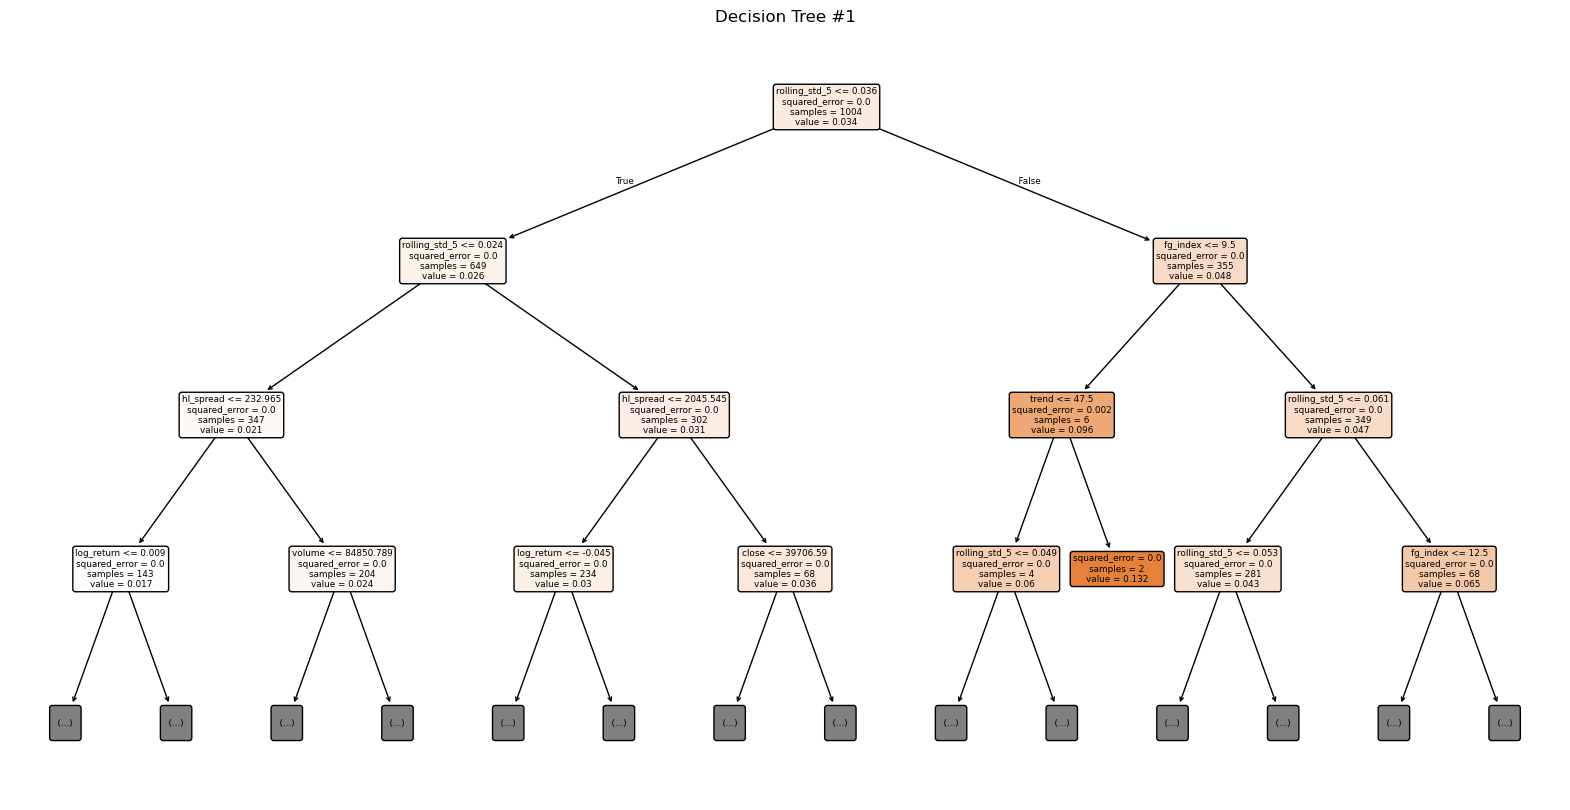

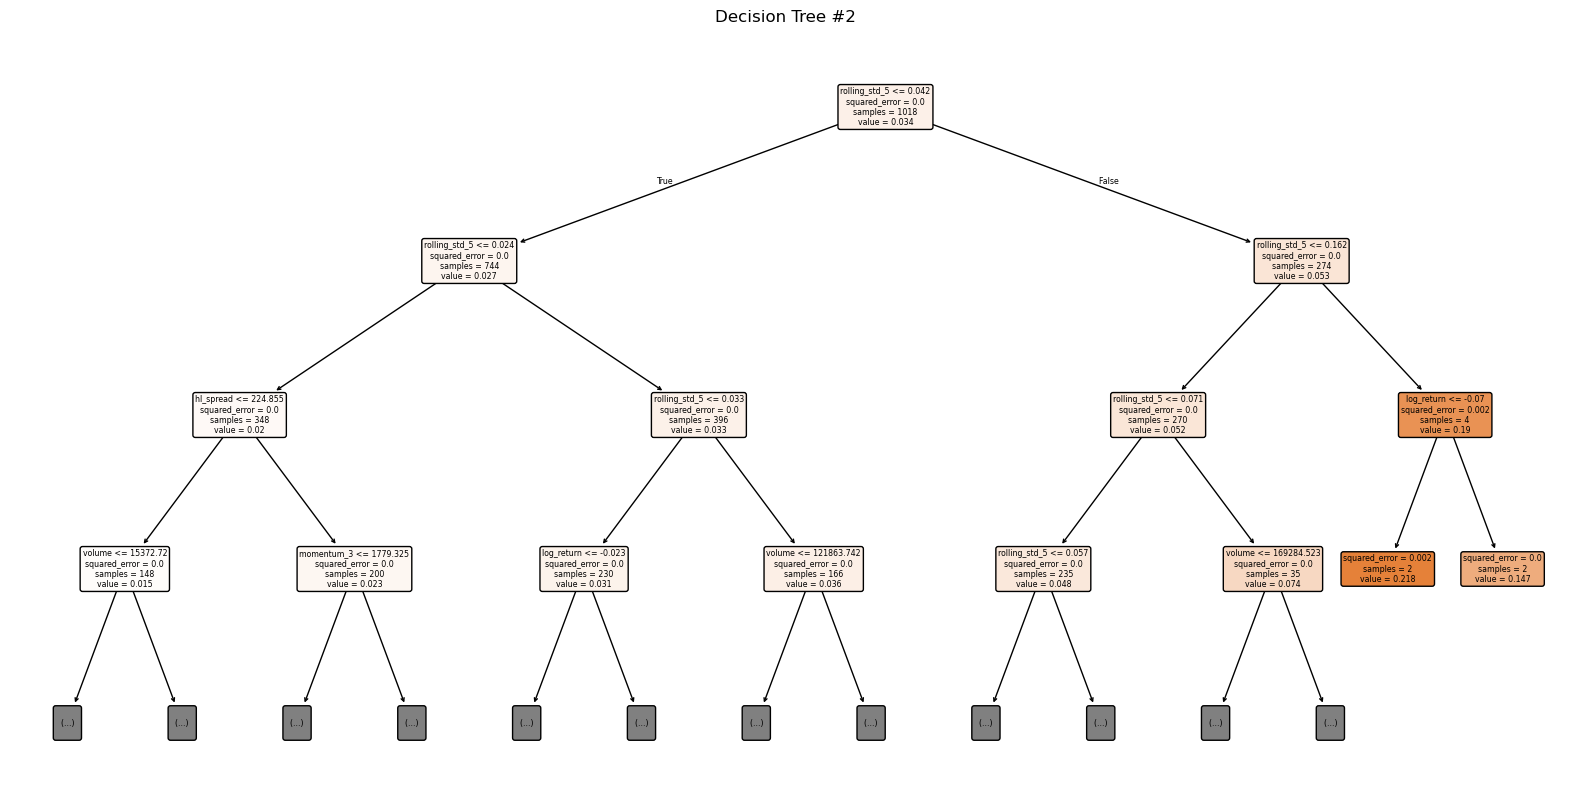

In [55]:
# Get the best Random Forest model
rf_model = rf_cv.best_estimator_

#define the # of trees to display
n_trees_to_plot = 2
#define how deep each tree should be
max_depth_to_show = 3

for i in range(n_trees_to_plot):
    estimator = rf_model.estimators_[i]
    
    plt.figure(figsize=(20, 10))
    plot_tree(estimator, 
              feature_names=X_tr_scal.drop(columns=['date']).columns, 
              filled=True, 
              rounded=True, 
              max_depth=max_depth_to_show)
    plt.title(f"Decision Tree #{i + 1}")
    plt.show()


Let's assess the random forest performances on the validation set.

In [56]:
#evaluate the model
rfval = evaluate_model(rf_cv, X_val.drop(columns=['date']), y_val, 'Random Forest')


Random Forest Performance on Validation Set:
RMSE: 0.0140
MAE: 0.0123
R²  : -0.0102


In [57]:
#add the line to the evalMetric table
add_evaluation(rfval, "Random Forest")

,Model,RMSE,MAE,R²
0,Baseline model: Mean,0.017954,0.015728,-0.660527
1,Linear Regression,0.022542,0.017061,-1.352012
2,Huber Regression,0.016168,0.012216,-0.209968
3,Lasso Regression,0.014026,0.012127,0.089442
4,Random Forest,0.014004,0.012306,-0.010204


In [58]:
#Save the model to "models" folder (commented out as it has already been run)
#with open(path+'rf_model_std.pickle', 'wb') as to_write:
   # pickle.dump(rf_cv, to_write)

### GRADIENT BOOSTING MACHINE: XGBOOST

Boosting is an ensamble technique building a sequence of weak learners, with each new learner attempting to correct its predecessor's errors. Specifically, XGBoosting is a tree-based Gradient Boosting Machine (GBM): it sets up decisions trees learning to predict the errors (residuals) left by the previous tree, effectively compensating for their mistakes.

As an ensamble method, XGBoost handles missing data, is robust to outliers and typically achieve high predictive accuracy. Plus, it controls overfitting coming from building a single-tree model. The main downside is that achieving high performance often requires  an in-depth tuning. Yet, with this analysis' approach (light-tune now, fine-tune later) this becomes an advantage: if a lightly-tuned XGboost manages to exceed the baseline models, it strongly suggests the dataset is well-suited for boosted tree methods.

Let's now instantiate the model, define the parameters grid and fit the Xgboost.

In [59]:
#instantiate the RF classifier
xgb_reg = XGBRegressor(random_state=1000)

In [60]:
#set the parameters
xgb_param = {'max_depth': [4,6,8], #how deep each base learner will grow
             'min_child_weight': [1,2,4,6], #a tree will not split a node if it results in any child node with less weight than this value
             'learning_rate': [0.01, 0.05, 0.1, 0.3], #weight given to each consecutive base learner's prediction
             'n_estimators': [100, 150, 200], #maximum number of base learner the ensamble will grow
             'colsample_bytree': [0.5, 1.0],
             'gamma': [0, 0.5, 1], #prevent unnecessary splits
             "subsample": [0.6, 1.0], #% of rows considered
             }

In [61]:
#Gridsearch the model
xgb_cv = GridSearchCV(xgb_reg, 
                     xgb_param, 
                     scoring= scoring,
                     cv=tscv, #5 folds
                     refit='RMSE', #main metric for refitting
                     n_jobs=-1,
                     verbose=1)

In [62]:
#load the model
with open(path+'xgb_model_std.pickle', 'rb') as to_read:
    xgb_cv = pickle.load(to_read)

In [63]:
#fit the model (commented as it has already been run)
#xgb_cv.fit(X_tr.drop(columns = ['date']), y_tr.values.ravel())

Once the model is fitted, its parameters and performances can be reviewed.

In [64]:
#show the xgb best parameters
print("Xgboosting's best parameters:")
xgb_cv.best_params_

Xgboosting's best parameters:


{'colsample_bytree': 1.0,
 'gamma': 0,
 'learning_rate': 0.01,
 'max_depth': 4,
 'min_child_weight': 6,
 'n_estimators': 150,
 'subsample': 0.6}

In [65]:
#evaluate the model
xgbval = evaluate_model(xgb_cv, X_val.drop(columns=['date']), y_val, 'XGBoosting')


XGBoosting Performance on Validation Set:
RMSE: 0.0116
MAE: 0.0103
R²  : 0.3044


In [66]:
#add the line to the evalMetric table
add_evaluation(xgbval, "XGBoosting")

,Model,RMSE,MAE,R²
0,Baseline model: Mean,0.017954,0.015728,-0.660527
1,Linear Regression,0.022542,0.017061,-1.352012
2,Huber Regression,0.016168,0.012216,-0.209968
3,Lasso Regression,0.014026,0.012127,0.089442
4,Random Forest,0.014004,0.012306,-0.010204
5,XGBoosting,0.011620,0.010304,0.304394


The XGboosting model beats the other models across every evaluation metrics. 

These results emphasize XGboost's capacity to capture data's non-linear structure while controlling for both data high variance and feature correlation. Moreover, as it was only ligthly tune, further improvements can be squeezed thanks to deeper tuning.

Considering XGBoost's strong results, the natural next step is to test another gradient boosting method requiring less training efforts: Light GBM.

In [67]:
#Save the model to "models" folder (commented as it has already been saved)
#with open(path+'xgb_model_std.pickle', 'wb') as to_write:
  #  pickle.dump(xgb_cv, to_write)

### LIGHT GBM

Light XGBoost, Light GBM is a gradient boosting machine employing tree-based learning algorithms. However, it differs from XGboosting in two main ways:

- Binning: LightGBM clusters the data into a fixed number of bins and assesses splits at the bin level. This reduces the amount of data considered, speeding up training.
- Leaf-wise growth: LightGBM grows just the leaf with the largest loss reduction at each step. This lead to deep asymmetric trees.

Together, these features make LightGBM more computationally efficient. However, due to its leaf-wise algorithm, it can fall more easily in the overfitting trap, if not properly tuned.

Let's build, define the parameter grid and assess the light GBM performances.

In [68]:
#initilize the GBM
lgbm_reg = LGBMRegressor(random_state=1000, verbose = -1)

In [69]:
#define the parameters
lgbm_param = {
    'num_leaves': [31, 50], #maximum number of tree's leaves
    'max_depth': [5, 10, -1], # maximum depth of the tree, -1 = no limit
    'learning_rate': [0.01, 0.1], #shrinks each tree's contribution
    'n_estimators': [100, 200], #boosting rounds
    'subsample': [0.8, 1.0], #row's fraction for sampling
    'colsample_bytree': [0.8, 1.0] #feature's fraction sampling
}

In [70]:
#perform the gridsearch
lgbm_cv = GridSearchCV(
    estimator=lgbm_reg,
    param_grid=lgbm_param,
    cv=tscv,
    scoring=scoring,
    refit = 'RMSE',
    verbose=1,
    n_jobs=-1
)

In [71]:
#load the model
with open(path+'lgbm_model_std.pickle', 'rb') as to_read:
    lgbm_cv = pickle.load(to_read)

In [72]:
#fit the model
#lgbm_cv.fit(X_tr.drop(columns = ['date']), y_tr.values.ravel())

In [73]:
#show the best params
print("Light GBM's best parameters:")
lgbm_cv.best_params_

Light GBM's best parameters:


{'colsample_bytree': 1.0,
 'learning_rate': 0.01,
 'max_depth': 5,
 'n_estimators': 200,
 'num_leaves': 31,
 'subsample': 0.8}

In [74]:
#evaluate the model
lgbmval = evaluate_model(lgbm_cv, X_val.drop(columns=['date']), y_val, 'Light GBM')


Light GBM Performance on Validation Set:
RMSE: 0.0112
MAE: 0.0098
R²  : 0.3512


In [75]:
#add to evalMetrics
add_evaluation(lgbmval, "Light GBM")

,Model,RMSE,MAE,R²
0,Baseline model: Mean,0.017954,0.015728,-0.660527
1,Linear Regression,0.022542,0.017061,-1.352012
2,Huber Regression,0.016168,0.012216,-0.209968
3,Lasso Regression,0.014026,0.012127,0.089442
4,Random Forest,0.014004,0.012306,-0.010204
5,XGBoosting,0.011620,0.010304,0.304394
6,Light GBM,0.011222,0.009757,0.351237


The LightGBM tops all the models.

In [76]:
#compute & display the % drops
print("")
print("Changes in LightGBM's Metrics with respect to XGBoost (training set):")
print("----------------------------------------------------------------------")
print(f"RMSE: {((lgbmval["RMSE"] / xgbval["RMSE"]) - 1)*100:.2f}%")
print(f"MAE: {((lgbmval["MAE"] / xgbval["MAE"]) - 1)*100:.2f}%")
print(f"R-squared: {((lgbmval["R²"] / xgbval["R²"]) - 1)*100:.2f}%")


Changes in LightGBM's Metrics with respect to XGBoost (training set):
----------------------------------------------------------------------
RMSE: -3.43%
MAE: -5.31%
R-squared: 15.39%


Next, a completly different algorithm is explored: Support Vector Regression (SVR).

In [77]:
#Save the model to "models" folder (commented as it has already been saved)
#with open(path+'lgbm_model_std.pickle', 'wb') as to_write:
 #   pickle.dump(lgbm_cv, to_write)

### SUPPORT VECTOR REGRESSION (SVR)

Support Vector Machine Regression (SVR) fits a regression function while keeping prediction errors within a predefined tolerance margin epsilon. It does so by building an epsilon-wide tube around the regression function: points within it are ignored, while those outside are penalized. Each violation's size is measured by the slack variables, and the importance of these violations is managed by C, a parameter determining how strictly the model enforces tolerance.

Moreover, SVR is fundamentally a linear method. When data is not linearly related (as in this case), SVR leverages the Kernel Trick to project the inputs into a higher-dimensional space where a linear relationship may exist. This is one of its main strength: the ability to "translate" into linear relatioships even nonlinear dataset. However, this capability comes at a cost: SVR is computationally expensive and requires careful hyperparameters tuning.

Let's initialize the model, define the parameters grid and evaluate the SVR model.

In [78]:
#initiate the model
svr = SVR()

In [79]:
# Define parameter grid (applies degree only when kernel is poly)
svr_param = [
    {
        'kernel': ['linear'],
        'C': [0.01, 0.05, 0.1, 0.5, 1, 10, 100],
        'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5, 1]
    },
    {
        'kernel': ['rbf'],
        'C': [0.01, 0.05, 0.1, 0.5, 1, 10, 100],               
        'gamma': [0.001, 0.005, 0.01, 0.05],     
        'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5, 1]  
    },
    {
        'kernel': ['poly'],
        'C': [0.01, 0.05, 0.1, 0.5, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01],
        'degree': [2, 3, 4],
        'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5, 1]         
    }
]

In [80]:
#define the gridsearch
svr_cv = GridSearchCV(svr,
                      svr_param,
                      cv=tscv,
                      scoring=scoring,
                      refit='RMSE',
                      verbose=1,
                      n_jobs=-1)

In [81]:
#load the model
with open(path+'svr_model_std.pickle', 'rb') as to_read:
    svr_cv = pickle.load(to_read)

In [82]:
%%time
#fit the model
#svr_cv.fit(X_tr_scal.drop(columns = ['date']), y_tr_scal.values.ravel())

CPU times: user 11 μs, sys: 1 μs, total: 12 μs
Wall time: 8.11 μs


In [83]:
#show the best parameters
print(svr_cv.best_params_)

{'C': 0.01, 'epsilon': 0.2, 'kernel': 'linear'}


In [84]:
#evaluate the model
svrval = evaluate_model(svr_cv, X_val_scal.drop(columns=['date']), y_val_scal, 'Support Vector Regression', scaler_y=scaler_y)


Support Vector Regression Performance on Validation Set:
RMSE: 0.0179
MAE: 0.0136
R²  : -0.4867


In [85]:
#add the evaluation to the table
add_evaluation(svrval, "Support Vector Regression")

,Model,RMSE,MAE,R²
0,Baseline model: Mean,0.017954,0.015728,-0.660527
1,Linear Regression,0.022542,0.017061,-1.352012
2,Huber Regression,0.016168,0.012216,-0.209968
3,Lasso Regression,0.014026,0.012127,0.089442
4,Random Forest,0.014004,0.012306,-0.010204
5,XGBoosting,0.011620,0.010304,0.304394
6,Light GBM,0.011222,0.009757,0.351237
7,Support Vector Regression,0.017922,0.013617,-0.486677


SVR outcomes are not particularly strong.

These results a) confirm the dataset non-linear structure; and b) points up the difficulties of uncovering a feature space where a linear relationship clearly emerges. The bitcoin's low singal-to-noise ration and ineherently high noise make this particularly challenging.

As shown by the model, spotting stable temporal patterns in this dataset is complex. Although Boosting algorithms achieved reasonably good performance, more flexible depp-learning architecture may uncover additional hidden structures. 

To explore this possibility, let's test a neural network widely used in finance: the long-short term memory (LSTM).

In [86]:
#Save the model to "models" folder (commented as it has already been saved)
#with open(path+'svr_model_std.pickle', 'wb') as to_write:
  #  pickle.dump(svr_cv, to_write)

### LONG-SHORT TERM MEMORY (LSTM)

**Note**. To check-out the complete LSTM building and tuning procedure, see [here](https://rsvjx0ig1ljkxul.studio.us-east-2.sagemaker.aws/studiolab/default/jupyter/lab/tree/sagemaker-studiolab-notebooks/LSTM-building%26Tuning.ipynb)

LSTM networks are a specialized kind of Recurrent Neural Newtwork designed to remember information over a long time horizon. In a nutshell, any LSTM's cell includes 3 gates operating sequentially:
- Forget gate: decides how much of previous state is forgotten
- Input gate: determines what new information should be stored in memory
- Output gate: Produces the output for the current time step and chooses what part of the internal state is passed forward.

As it keeps memory over long sequences, LSTMs shine when modeling sequential data where the past context affects the present.

Nevertheless, LSTMs are computationally intensive and require a substantial amount of training data to properly generalize. This last point may be a key limitation of the considered dataset.

Let's load the LSTM and show its outcomes. But first, data must be transformed into a format suitable for LSTM input. 

**Note.** The LSTM model was fine-tuned using 3 TimeSeriesSplit folds (to balance runtime and stability), while tree-based and kernel models were tuned with 4 folds. All models were evaluated on the same hold-out validation set for fair comparison.

In [87]:
# Generate sequences and targets for LSTM with window size 20 for validation
x_lstm_val, y_lstm_val = create_sequences_from_X_y(X_tr_scal, y_tr_scal, window_size=20)
#windows_size tells how much the model looks back to predict the next point (ex if = 20, model looks at the last 20 observations to predict the next one)
#it is the length of each input sequence and corresponding target.

In [88]:
# Generate sequences and targets for LSTM with window size 20 for validation
x_lstm_val, y_lstm_val = create_sequences_from_X_y(X_val_scal, y_val_scal, window_size=20)
#windows size = as training

In [89]:
#define the LSTM storing path
lstm_path = "models_forecasting/LSTM/LSTM_champion/LSTM.keras"
#load the model
lstm = keras.models.load_model(lstm_path)
#check the model has been loaded by displaying its architecture & params
lstm.summary()

2026-02-25 21:29:50.238596: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential_115"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_108              │ (None, 20, 10)         │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_115 (LSTM)                 │ (None, 128)            │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_114 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 213,893 (835.52 KB)

 Trainable params: 71,297 (278.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 142,596 (557.02 KB)

In [90]:
#evaluate the already-tuned LSTM
lstmval = evaluate_model(lstm, x_lstm_val, y_lstm_val, "LSTM",scaler_y=scaler_y)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step

LSTM Performance on Validation Set:
RMSE: 0.0175
MAE: 0.0146
R²  : -0.7143


In [91]:
#add the evaluation to the table
add_evaluation(lstmval, "LSTM NN")

,Model,RMSE,MAE,R²
0,Baseline model: Mean,0.017954,0.015728,-0.660527
1,Linear Regression,0.022542,0.017061,-1.352012
2,Huber Regression,0.016168,0.012216,-0.209968
3,Lasso Regression,0.014026,0.012127,0.089442
4,Random Forest,0.014004,0.012306,-0.010204
5,XGBoosting,0.011620,0.010304,0.304394
6,Light GBM,0.011222,0.009757,0.351237
7,Support Vector Regression,0.017922,0.013617,-0.486677
8,LSTM NN,0.017455,0.014646,-0.714258


As the evaluation table displays, boosting methods consistently yield strong results. However, in finance even small prediction errors can lead to significant costs. As a consequence, incorporating uncertainty estimates becomes valuable in this case.

To do that, let's implement a model providing probabilitsic predictions with interval estimates: NGBoost.

### NGBOOST

NGBoost is a relatively recent technique extending traditional gradient boosting by predicting full-probability distributions over the target variable. By employing natural gradients and allowing for heteroskedasticity, NGBoost optimizes the data likelihood under a chosen parametric distribution. As such, instead of producing single-point estimations, it forecasts all the parameters of the target's probability distribution.

These properties make NGBoost extremely useful in high-stakes contexts where uncertainty quantification is crucial. By modeling the entire predictive distribution, it can forecast ranges within the target parameter will lie with a given confidence interval, allowing it to improve decision-making under uncertainty.

Let's implement the model and see how it performs.

In [92]:
#initiate the model
ngb_reg = NGBRegressor(
    Dist=Normal,         # Target distribution (Normal for regression)
    Score=MLE,         # Loss based on Maximum Likelihood
    verbose=False,       # Keep training output quiet
    random_state=1000
)

In [93]:
#define the parameters grid2
ngb_param = {
    "n_estimators": [500, 1000],
    "learning_rate": [0.01, 0.03],
    "min_samples_leaf": [20, 50],
    "max_depth": [3],
    "minibatch_frac": [0.6, 1.0], #Fraction of data for each boosting iteration
    "col_sample": [1.0, 0.8] #Random feature subsampling
}

In [94]:
#define the gridSearch
ngb_cv = GridSearchCV(
    estimator = ngb_reg,
    param_grid = ngb_param,
    cv = tscv,
    scoring = scoring, 
    refit = "RMSE",
    verbose = 1
)

In [95]:
#ngb_cv.fit(X_tr.drop(columns = ['date']), y_tr.values.ravel())

In [96]:
#load the model
with open(path+'ngb_model_std.pickle', 'rb') as to_read:
    ngb_cv = pickle.load(to_read)

In [97]:
#show the top-performing parameters
print("NGBoosting Best Parameters:", ngb_cv.best_params_)

NGBoosting Best Parameters: {'col_sample': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 50, 'minibatch_frac': 1.0, 'n_estimators': 500}


In [98]:
#Get best estimator from the tuned GridSearchCV
best_ngb = ngb_cv.best_estimator_

# Inspect uncertainty
#predict the distribution of each point
dist = best_ngb.pred_dist(X_val.drop(columns=['date']))
#get an array of the scale paramters (std for normal)
pred_stds = dist.scale
#average the predicted std to know how uncertain is the model on average
print(f"Average predicted standard deviation: {np.mean(pred_stds):.4f}")

Average predicted standard deviation: 0.0085


In [99]:
#evaluate the model
ngbval = evaluate_model(ngb_cv, X_val.drop(columns=['date']), y_val, 'NgBoosting')


NgBoosting Performance on Validation Set:
RMSE: 0.0149
MAE: 0.0123
R²  : -0.1492


In [100]:
#add the evaluation to the table
add_evaluation(ngbval, "NGBoosting (mean)")

,Model,RMSE,MAE,R²
0,Baseline model: Mean,0.017954,0.015728,-0.660527
1,Linear Regression,0.022542,0.017061,-1.352012
2,Huber Regression,0.016168,0.012216,-0.209968
3,Lasso Regression,0.014026,0.012127,0.089442
4,Random Forest,0.014004,0.012306,-0.010204
5,XGBoosting,0.011620,0.010304,0.304394
6,Light GBM,0.011222,0.009757,0.351237
7,Support Vector Regression,0.017922,0.013617,-0.486677
8,LSTM NN,0.017455,0.014646,-0.714258
9,NGBoosting (mean),0.014936,0.012301,-0.149181


In [101]:
#Save the model to "models" folder (commented as it has already been saved)
#with open(path+'ngb_model_std.pickle', 'wb') as to_write:
  #  pickle.dump(ngb_cv, to_write)

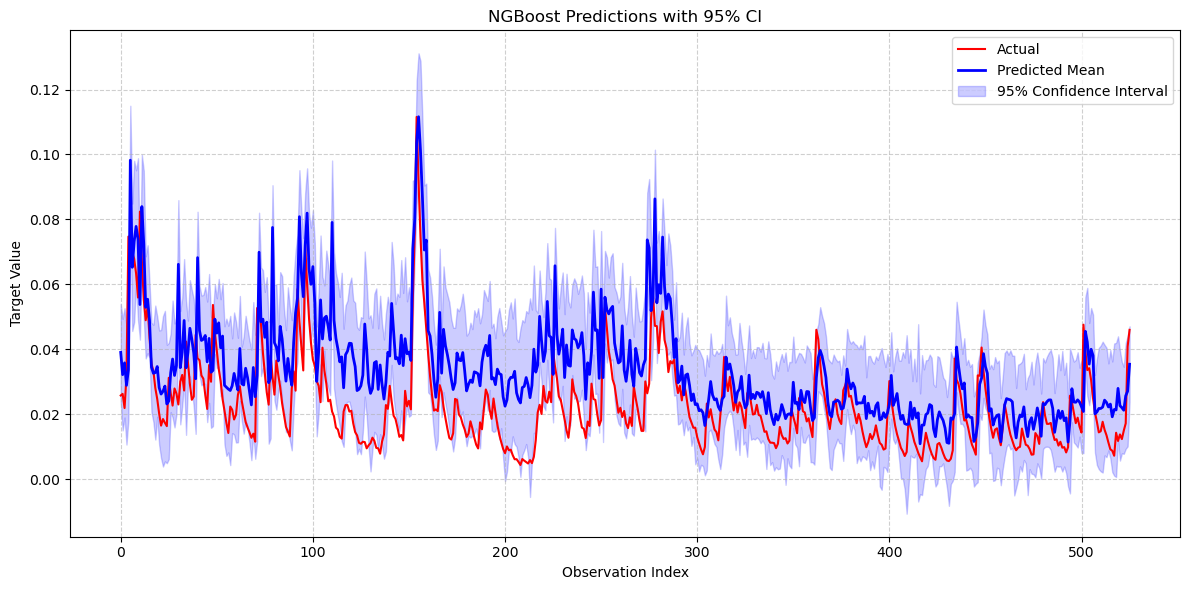

In [102]:
#show predictions w/ intervals
plot_ngboost_predictions(best_ngb, X_val.drop(columns=['date']), y_val, scaler_y=None)

In [103]:
#compute coverage
coverage_int = coverage(best_ngb, X_val.drop(columns=["date"]), y_val, alpha=0.95, scaler_y=scaler_y)
#compute NLL
nll = nll_score(best_ngb, X_val.drop(columns=["date"]), y_val, scaler_y=scaler_y)
#compute CRPS
crps = crps_score(best_ngb, X_val.drop(columns=["date"]), y_val, scaler_y=scaler_y)
#report results
print("Uncertainty evaluation metrics:")
print(f"95% Prediction Interval Coverage: {coverage_int:.3f}")
print(f"NLL: {nll:.4f}")
print(f"CRPS: {crps:.4f}")

Uncertainty evaluation metrics:
95% Prediction Interval Coverage: 0.751
NLL: -6.2527
CRPS: 0.0002


In terms of uncertainty estimations, the NGBoost model shows some room for improvement.
 
To address this imbalance, let's apply a post-hoc variance scaling to improve calibration.

In [104]:
#define the distribution from the best NGBoost
dist = best_ngb.pred_dist(X_val.drop(columns=["date"]))
#get the predicted mean
mu = np.array(dist.loc).ravel()
#get the predicted std
sigma = np.array(dist.scale).ravel()
#flatten Y_val
y_true_flat = np.array(y_val).ravel()

# compute z for 95% interval
coverage_target = 0.95
z = norm.ppf(0.5 + coverage_target / 2)

#look for optimal scaling factor
best_factor = None
best_coverage_diff = np.inf
# try factors from 1x to 3x
for f in np.linspace(1.0, 3.0, 50):
    lower_try = mu - z * sigma * f
    upper_try = mu + z * sigma * f
    coverage_try = np.mean((y_true_flat >= lower_try) & (y_true_flat <= upper_try))
    diff = abs(coverage_try - coverage_target)
    #store the best factor
    if diff < best_coverage_diff:
        best_coverage_diff = diff
        best_factor = f
#print the optimal scaling factor
print("")
print("Optimal scaling factor:", best_factor)
#Get final intervals (mean +- z * std*scaler)
lower_scaled = mu - z * sigma * best_factor
upper_scaled = mu + z * sigma * best_factor

print("")
print("Scaled Uncertainty evaluation metrics:")
print("---------------------------------------")

#Compute the final scaled coverage
scaled_coverage = np.mean((y_true_flat >= lower_scaled) & (y_true_flat <= upper_scaled))
print(f"Scaled 95% Prediction Interval Coverage: {scaled_coverage:.4f}")

# applying scaling to sigma
sigma_scaled = sigma * best_factor

# scaled NLL
nll_scaled = -np.mean(norm.logpdf(y_true_flat, loc=mu, scale=sigma_scaled))
print(f"NLL with scaled intervals: {nll_scaled:.6f}")

# scaled CRPS
z = (y_true_flat - mu) / sigma_scaled
crps = sigma_scaled * ( z * (2*norm.cdf(z) - 1) + 2*norm.pdf(z) - 1/np.sqrt(np.pi) )
crps_scaled = np.mean(crps)
print(f"CRPS with scaled intervals: {crps_scaled:.6f}")



Optimal scaling factor: 1.5714285714285714

Scaled Uncertainty evaluation metrics:
---------------------------------------
Scaled 95% Prediction Interval Coverage: 0.9506
NLL with scaled intervals: -2.823070
CRPS with scaled intervals: 0.008306


By scaling the variance, coverage drastically improved, reaching a value really close to the nominal level. This points to excellent calibration, meaning that around 95% of the observed values lie within the model's prediction intervals

Overall, the scaled model provides more reliable and better-calibrated uncertainty estimates while preserving accurate point-predictions. 

Let's visualize the predicted-vs-actual plot to visually check this.

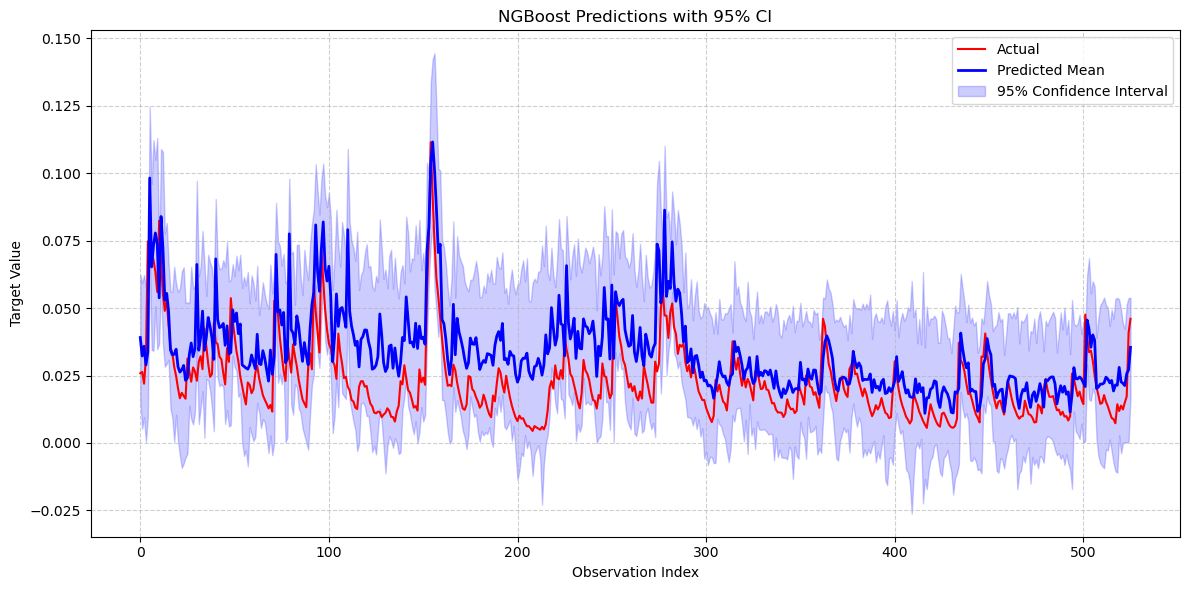

In [105]:
#show predictions w/ intervals
plot_ngboost_predictions(best_ngb, X_val.drop(columns=['date']), y_val, scaler_y=None, variance_scale=best_factor)

As the chart shows, even when the point point prediction deviates from the observed value, the latter often falls within the predicted confidence interval. This is desiderable: the uncertainty band explicitly accounts for potential differences from the mean forecast. This allows the model to capture extreme situations that the single-point estimation alone would miss.

### TRANSFORMERS

Transformers are an advanced deep-learning architecture transforming input sequences into output sequences. Through a self-attention mechanism, transformers process entire sequences of data in parallel. This allows to model long-range dependencies. To do that, transformers typically need large amounts of training data, substantial computational resources (often are run on GPU) and careful tuning. 

As a consequence, in small or moderate size time-series datasets they may not perform as expected, leading to overfitting or unstable learning. This is likely the main limit in the dataset considered in this analysis.

Let's build a baseline transformer to assess whether it could be a good fit in this specicic case.

Note. Transformers generally require scaled input features.

In [ ]:
##create transfomers sequences
#training
X_trans_tr, y_trans_tr = create_transformer_sequences(X_tr_scal, y_tr_scal, window_size = 20, forecast_horizon=1)
#validation
X_trans_val, y_trans_val = create_transformer_sequences(X_val_scal, y_val_scal, window_size = 20, forecast_horizon=1)

# Create datasets
train_dataset = TimeSeriesDataset(X_trans_tr, y_trans_tr)
val_dataset = TimeSeriesDataset(X_trans_val, y_trans_val)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)  # shuffle only training
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)     # no shuffle for validation

In [ ]:
#select GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
#instantiate baseline model
model = TimeSeriesTransformer(
    n_features=X_trans_tr.shape[2], #number of input features x timestep
    d_model=64, #embedding dimension
    n_heads=4, #number of attention heads
    n_layers=3, #number of transformer encoder layers
    dropout = 0.2 
).to(device) #move model to device

#define Mean Squared Error as the loss function
criterion = nn.MSELoss()
#adam optimizer to update model params with learning_rate = 5e-4
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

In [ ]:
%%time
#define the n of training epochs
epochs= 50
#loop through epochs
for epoch in range(epochs):

    #### TRAINING
    model.train()
    #initilize cumulative training loss
    train_loss = 0.0
    #loop trhough all mini-batches in the training DataLoader
    for X_batch, y_batch in train_loader:
        #move input to device
        X_batch = X_batch.to(device)
        #move target to device
        y_batch = y_batch.to(device)

        #resets gradients from previous iteration
        optimizer.zero_grad()
        #get model predictions for this batch (1-step forward)
        preds = model(X_batch)
        #compute prediction-vs-actual loss
        loss = criterion(preds, y_batch)
        #backpropagation to compute gradients
        loss.backward()
        #update model's parameters using the optimizer
        optimizer.step()
        #accumulate batch loss
        train_loss += loss.item()
    #compute average training loss across all batches
    train_loss /= len(train_loader)

    #### VALIDATION
    model.eval()
    #initilize cumulative validation loss
    val_loss = 0.0
    #disable gradient calculation during validation to speed things up
    with torch.no_grad():
        #loop through all validation batches
        for X_batch, y_batch in val_loader:
            #move validation inputs to device
            X_batch = X_batch.to(device)
            #move validation target to device
            y_batch = y_batch.to(device)

            #get predictions on validation data
            preds = model(X_batch)
            #compute batch's loss
            loss = criterion(preds, y_batch)
            #accumulate validation loss
            val_loss += loss.item()
    #compute avg validation loss over all validation batches
    val_loss /= len(val_loader)

    #print summary
    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train MSE: {train_loss:.4f} | "
        f"Val MSE: {val_loss:.4f}"
    )

In [ ]:
#set the model in evaluation mode
model.eval()
#intialize an empty list for stroing true target values
y_true_transf = []
#intialize an empty list for stroing predicted target values
y_pred_transf = []

#disable gradient computation (saves memory and speed up)
with torch.no_grad():
    #loop through all batches in the validation DataLoader
    for X_batch, y_batch in val_loader:
        #move the input batch to the same device as the model
        X_batch = X_batch.to(device)
        #get model predictions, get them back to CPU & convert into numpy
        preds_transf = model(X_batch).cpu().numpy()
        #store current batch true labels
        y_true_transf.append(y_batch.numpy())
        #store current batch predictions
        y_pred_transf.append(preds_transf)

#concatenate all stored true values
y_true_transf = np.concatenate(y_true_transf)
#concated all the predicted values
y_pred_transf = np.concatenate(y_pred_transf)

#inverse scale true values
y_true_transf = scaler_y.inverse_transform(y_true_transf.reshape(-1,1)).ravel()
#inverse scale predictions
y_pred_transf = scaler_y.inverse_transform(y_pred_transf.reshape(-1,1)).ravel()

In [ ]:
#compute rmse
transf_rmse = np.sqrt(mean_squared_error(y_true_transf, y_pred_transf))
transf_mae = mean_absolute_error(y_true_transf, y_pred_transf)
transf_r = r2_score(y_true_transf, y_pred_transf)

#show them
print("")
print("Baseline Transformer's Evaluation metrics:")
print("------------------------------------------")
print(f"RMSE: {transf_rmse:.3f}")
print(f"MAE: {transf_mae:.3f}")
print(f"R2: {transf_r:.3f}")

### TRANSFORMER AS FEATURE EXTRACTOR

Transformers are a highly valuable resource for feature engineering a dataset. Through their embedding mechanisms, they are able to generate high-level latent representation that can be subsequently integrated into more traditional ML models. In this analysis, two distinguished transformer-based approaches are developed:

- **Unsupervised transformer with masked time-series modeling**: By feeding 90-days windows data without a target value, the unsupervised transformer reads the multivariate sequence and compresses it into one latent vector. This representations works as a proxy of the underlying market context, gathering regime characteristics, interactions among features and volatility clustering patterns.
- **Supervised transformer with penultimate-layer extraction**: A supervised transformer is trained to directly predict the volatility target. Rather than using its final prediction alone, the latent representation from the penultimate layer is kept as a sort of "learned volatility risk factor". This is a feature explicitly optimized to explain volatility. Hence, it should carry strong predictive power.

In both cases, the resulting vectors are passed through a Principal Component Analysis (PCA) to control for dimensionality. In detail, as many PCs as necessary to explain 95% of variance are kept. These components are then appended to the original feature set, and the enriched dataset is used to re-train the previously identified top-performing model. In the end, performances are assessed and compared as usual.

### APPROACH #1: UNSUPERVISED TRANSFORMER WITH MASKED TIME-SERIES MODELING

#### Transformer training & PCA for the training set

In [ ]:
#build transformer ready rolling window (x-only as the masked transformer is unsupervised)
X_trans_fe, _ = create_transformer_sequences(X_tr_scal,
                                             y_tr_scal, 
                                             window_size=90, #90-days sequences
                                             forecast_horizon=1) #1-step forecast alignment
#convert numpy window into a Pytorch tensor
fe_windows = torch.tensor(X_trans_fe, dtype=torch.float32)
#wrap the tensor inside a tensordataset
fe_dataset = TensorDataset(fe_windows)
#create a dataloader to feed data in mini-batches during traning
fe_loader = DataLoader(fe_dataset, batch_size=16, shuffle=True)

In [ ]:
#initilize model
fe_model = MaskedTimeSeriesTransformer(feature_dim=fe_windows.shape[-1], #number of input feat x timestep
                                    embed_dim=32, #embedding gimension
                                    num_heads=2, #attention heads
                                    num_layers=2) #transformers' encoder layers
#train the model with small batches (50 epochs)
train_model_batch(fe_model, fe_loader, epochs=50, mask_ratio=0.2)

In [ ]:
#extract embeddings
fe_embeddings = extract_embeddings(fe_model, fe_windows)
print("Embedding shape:", fe_embeddings.shape)

In [ ]:
# Convert embeddings to DataFrame
emb_df = pd.DataFrame(fe_embeddings.numpy(), columns=[f"emb_{i}" for i in range(32)])
emb_df['date'] = X_tr_scal['date'].values[90:]  # align dates

In [ ]:
#initilize PCA
pca = PCA()
#fit PCA on the embedded df
emb_pca = pca.fit_transform(emb_df.drop(columns='date'))

In [ ]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [ ]:
# Keep components that explain 95% of variance (6 components)
pca_95 = PCA(n_components=6)
df_pca_reduced = pca_95.fit_transform(emb_df.drop(columns='date'))
#print the PCA shape
print(f'Shape after PCA: {df_pca_reduced.shape}')

In [ ]:
#transform into a df
pca_df = pd.DataFrame(df_pca_reduced)
#rename columns
pca_df = pca_df.rename(columns={0: 'PC1', 1: 'PC2', 2: 'PC3', 3: 'PC4', 4: 'PC5', 5: "PC6"})
#show it
pca_df.head(5)

In [ ]:
#drop the first 90 rows (are NaN due to windows) of X_tr_scal
X_tr_scal_align = X_tr_scal.iloc[90:].reset_index(drop=True)
#reset the index for pca
pca_df = pca_df.reset_index(drop=True)
#merge the dfs (PCs + previous features)
X_tr_pca = pd.concat([X_tr_scal_align, pca_df], axis=1)
#show it
X_tr_pca.head(5)

In [ ]:
#check there are no null
X_tr_pca.isnull().sum()

In [ ]:
#chop y-target too
y_tr_pca = y_tr_scal.iloc[90:].reset_index(drop=True)

#### Transformer and PCA for Validation set

In [ ]:
# build validation transformer window (the same as for training)
X_val_seq, _ = create_transformer_sequences(
    X_val_scal,
    y_val_scal,
    window_size=90,
    forecast_horizon=1
)
# Convert to tensor
val_windows = torch.tensor(X_val_seq, dtype=torch.float32)

In [ ]:
#set to evaluation mode (no training, just preds)
model.eval()
#disable gradient computation
with torch.no_grad():
    #pass val window through the trained transformer to get hidden states
    _, val_hidden = fe_model(val_windows)
    #apply mean pooling across the time dimensions to obtain fixed-size emebddings
    val_embeddings = val_hidden.mean(dim=1)
#print the shape for embeddings for checking
print("Validation embedding shape:", val_embeddings.shape)

In [ ]:
#Convert val emb to a df with same column names used during training
val_emb_df = pd.DataFrame(
    val_embeddings.numpy(),
    columns=[f"emb_{i}" for i in range(val_embeddings.shape[1])]
)
#PCA with 95% explained variance
val_pca = pca_95.transform(val_emb_df)
#show it
print("Validation PCA shape:", val_pca.shape)

In [ ]:
#transform to df
pca_df_val = pd.DataFrame(val_pca)
#rename columns 
pca_df_val = pca_df_val.rename(columns={0: 'PC1', 1: 'PC2', 2: 'PC3', 3: 'PC4', 4: 'PC5', 5: "PC6"})
#show them
pca_df_val.head(5)

In [ ]:
#drop the first 90 rows 
X_val_scal_align = X_val_scal.iloc[90:].reset_index(drop=True)
#reset the index for pca
pca_df_val = pca_df_val.reset_index(drop=True)
#merge the df 
X_val_pca = pd.concat([X_val_scal_align, pca_df_val], axis=1)
#show it
X_val_pca

In [ ]:
#check for missing values
X_val_pca.isnull().sum()

In [ ]:
#chop y-target too
y_val_pca = y_val_scal.iloc[90:].reset_index(drop=True)

#### Enriched dataset & top-performing model: light-tuning & assessment

In [ ]:
#Gridsearch the xgboost model (same seed and params as before)
fe_lgbm_cv = GridSearchCV(lgbm_reg, 
                     lgbm_param, 
                     scoring= scoring,
                     cv=tscv, #5 folds
                     refit='RMSE', #main metric for refitting
                     n_jobs=-1,
                     verbose=1)

In [ ]:
%%time
#fit the model (commented out if already run)
#fe_lgbm_cv.fit(X_tr_pca.drop(columns = ['date']), y_tr_pca.values.ravel())

In [ ]:
#load the model
with open(path+'felgbm_model_std.pickle', 'rb') as to_read:
    fe_lgbm_cv = pickle.load(to_read)

In [ ]:
#evaluate the model
felgbmval = evaluate_model(fe_lgbm_cv, X_val_pca.drop(columns=['date']), y_val_pca,
               "XGboost + Context", scaler_y = scaler_y)

In [ ]:
# add evaluation to the table
add_evaluation(felgbmval, "XGboost + Context")

In [ ]:
#Save the model to "models" folder (commented as it has already been saved)
#with open(path+'felgbm_model_std.pickle', 'wb') as to_write:
 #  pickle.dump(fe_lgbm_cv, to_write)

### APPROACH #2: SUPERVISED TRANSFORMER WITH PENULTIMATE LAYER EXTRACTION

#### Penultimate layer extraction & PCA: training set

In [ ]:
#embeddings in the training set
train_loader_emb = DataLoader(train_dataset, batch_size=128, shuffle=False) #no shuffle as this is forecasting
#set the model in evaluation mode
model.eval()
#intialize an empty list for storing true target values
y_true_transf_tr = []
#intialize an empty list for storing predicted target values
y_pred_transf_tr = []
#store the embeddings
transf_embeddings_tr = []

#disable gradient computation (saves memory and speed up)
with torch.no_grad():
    #loop through all batches in the validation DataLoader
    for X_batch, y_batch in train_loader_emb:
        #move the input batch to the same device as the model
        X_batch = X_batch.to(device)
        #get model predictions & embeddings
        preds_transf, hidden = model(X_batch, return_hidden=True)
        #get them back to CPU & convert into numpy
        preds_transf = preds_transf.cpu().numpy()
        hidden = hidden.cpu().numpy()
        #store current batch true labels
        y_true_transf_tr.append(y_batch.numpy())
        #store current batch predictions
        y_pred_transf_tr.append(preds_transf)
        #store current batch embeddings
        transf_embeddings_tr.append(hidden)

#concatenate all stored true values
y_true_transf_tr = np.concatenate(y_true_transf_tr)
#concated all the predicted values
y_pred_transf_tr = np.concatenate(y_pred_transf_tr)
# concatenate all the embeddings
transf_embeddings_tr = np.concatenate(transf_embeddings_tr)

#print to confirm
print("Embedding shape:", transf_embeddings_tr.shape)

In [ ]:
#fit PCA on the embedded df
emb_pca_emb = pca.fit_transform(transf_embeddings_tr)

In [ ]:
# Explained variance ratio
explained_variance_emb = pca.explained_variance_ratio_
cumulative_variance_emb = np.cumsum(explained_variance_emb)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_emb) + 1), cumulative_variance_emb, marker='o', linestyle='--')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [ ]:
#pca on embeddings
# Keep 9 components (they explain around 95% of variance)
pca_95_emb = PCA(n_components=9)
embeddings_tr_pca = pca_95_emb.fit_transform(transf_embeddings_tr)
#print the PCA shape
print(f'Shape after PCA: {embeddings_tr_pca.shape}')

In [ ]:
#transform to df
embeddings_tr_pca = pd.DataFrame(embeddings_tr_pca)
#rename columns 
embeddings_tr_pca = embeddings_tr_pca.rename(columns={0: 'PC1-pen', 1: 'PC2-pen', 2: 'PC3-pen', 3: 'PC4-pen', 4: 'PC5-pen',
                                                     5: 'PC6-pen', 6: 'PC7-pen', 7: 'PC8-pen', 8: 'PC9-pen'})
#show them
embeddings_tr_pca.head(5)

In [ ]:
#drop the first 20 rows (are NaN due to windows = 20 in transformers) of X_tr_scal
X_tr_scal_emb = X_tr_scal.iloc[20:].reset_index(drop=True)
#reset the index for pca
embeddings_tr_pca = embeddings_tr_pca.reset_index(drop=True)
#merge the dfs (PCs + previous features)
X_tr_emb_pca = pd.concat([X_tr_scal_emb, embeddings_tr_pca], axis=1)
#show it
X_tr_emb_pca.head(5)

#### Penultimate layer extraction & PCA: validation set

In [ ]:
#set the model in evaluation mode
model.eval()
#intialize an empty list for storing true target values
y_true_transf_val = []
#intialize an empty list for storing predicted target values
y_pred_transf_val = []
#store the embeddings
transf_embeddings_val = []

#disable gradient computation (saves memory and speed up)
with torch.no_grad():
    #loop through all batches in the validation DataLoader
    for X_batch, y_batch in val_loader:
        #move the input batch to the same device as the model
        X_batch = X_batch.to(device)
        #get model predictions & embeddings
        preds_transf, hidden = model(X_batch, return_hidden=True)
        #get them back to CPU & convert into numpy
        preds_transf = preds_transf.cpu().numpy()
        hidden = hidden.cpu().numpy()
        #store current batch true labels
        y_true_transf_val.append(y_batch.numpy())
        #store current batch predictions
        y_pred_transf_val.append(preds_transf)
        #store current batch embeddings
        transf_embeddings_val.append(hidden)

#concatenate all stored true values
y_true_transf_val = np.concatenate(y_true_transf_tr)
#concated all the predicted values
y_pred_transf_val = np.concatenate(y_pred_transf_tr)
# concatenate all the embeddings
transf_embeddings_val = np.concatenate(transf_embeddings_val)

#print to confirm
print("Embedding shape:", transf_embeddings_val.shape)

In [ ]:
#pca on embeddings
# Keep components that explain 95% of variance
embeddings_val_pca = pca_95_emb.transform(transf_embeddings_val)
#print the PCA shape
print(f'Shape after PCA: {embeddings_val_pca.shape}')

In [ ]:
#transform to df
embeddings_val_pca = pd.DataFrame(embeddings_val_pca)
#rename columns 
embeddings_val_pca = embeddings_val_pca.rename(columns={0: 'PC1-pen', 1: 'PC2-pen', 2: 'PC3-pen', 3: 'PC4-pen', 4: 'PC5-pen',
                                                     5: 'PC6-pen', 6: 'PC7-pen', 7: 'PC8-pen', 8: 'PC9-pen'})
#show them
embeddings_val_pca.head(5)

In [ ]:
#drop the first 20 rows (are NaN due to windows = 20 in transformers) of X_tr_scal
X_val_scal_emb = X_val_scal.iloc[20:].reset_index(drop=True)
#reset the index for pca
embeddings_val_pca = embeddings_val_pca.reset_index(drop=True)
#merge the dfs (PCs + previous features)
X_val_emb_pca = pd.concat([X_val_scal_emb, embeddings_val_pca], axis=1)
#show it
X_val_emb_pca.head(5)

#### Enriched dataset & top-performing model: light-tuning & assessment

In [ ]:
#chop training target too
y_tr_emb = y_tr_scal.iloc[20:].reset_index(drop=True)
#chop val target too
y_val_emb = y_val_scal.iloc[20:].reset_index(drop=True)

In [ ]:
#Gridsearch the xgboost model (same seed and params as before)
emb_lgbm_cv = GridSearchCV(lgbm_reg, 
                     lgbm_param, 
                     scoring= scoring,
                     cv=tscv, #5 folds
                     refit='RMSE', #main metric for refitting
                     n_jobs=-1,
                     verbose=1)

In [ ]:
#load the model
with open(path+'emblgbm_model_std.pickle', 'rb') as to_read:
    emb_lgbm_cv = pickle.load(to_read)

In [ ]:
%%time
#fit the model (commented out if already run)
#emb_lgbm_cv.fit(X_tr_emb_pca.drop(columns = ['date']), y_tr_emb.values.ravel())

In [ ]:
#evaluate the model
emblgbmval = evaluate_model(emb_lgbm_cv, X_val_emb_pca.drop(columns=['date']), y_val_emb,
               "Emb_LightBoost", scaler_y = scaler_y)

In [ ]:
#add evaluation to the table
add_evaluation(emblgbmval, "LightBoost + Pen Embedding")

In [ ]:
#Save the model to "models" folder (commented as it has already been saved)
#with open(path+'emblgbm_model_std.pickle', 'wb') as to_write:
 #   pickle.dump(emb_lgbm_cv, to_write)

### OPTION #3: CONTEXT & VOLATILITY EMBEDDING

#### Dataset set-up

In [ ]:
#drop the first 90 rows 
embeddings_tr_pca_90 = embeddings_tr_pca.iloc[70:].reset_index(drop=True)
#reset the index for pca
X_tr_pca = X_tr_pca.reset_index(drop=True)
#merge the df 
X_tr_tot = pd.concat([X_tr_pca, embeddings_tr_pca_90], axis=1)
#show it
X_tr_tot.head(5)

In [ ]:
#drop the first 90 rows 
embeddings_val_pca_90 = embeddings_val_pca.iloc[70:].reset_index(drop=True)
#reset the index for pca
X_val_pca = X_val_pca.reset_index(drop=True)
#merge the df 
X_val_tot = pd.concat([X_val_pca, embeddings_val_pca_90], axis=1)
#show it
X_val_tot.head(5)

#### Enriched dataset & Top-performing model: light-tuning & assessment

In [ ]:
#Gridsearch the xgboost model (same seed and params as before)
tot_lgbm_cv = GridSearchCV(lgbm_reg, 
                     lgbm_param, 
                     scoring= scoring,
                     cv=tscv, #5 folds
                     refit='RMSE', #main metric for refitting
                     n_jobs=-1,
                     verbose=1)

In [ ]:
#chop training target too
y_tr_tot = y_tr_scal.iloc[90:].reset_index(drop=True)
#chop val target too
y_val_tot = y_val_scal.iloc[90:].reset_index(drop=True)

In [ ]:
%%time
#fit the model (commented out if already run)
#tot_lgbm_cv.fit(X_tr_tot.drop(columns = ['date']), y_tr_tot.values.ravel())

In [ ]:
#load the model
with open(path+'totlgbm_model_std.pickle', 'rb') as to_read:
    tot_lgbm_cv = pickle.load(to_read)

In [ ]:
#evaluate the model
totlgbmval = evaluate_model(tot_lgbm_cv, X_val_tot.drop(columns=['date']), y_val_pca,
               "LightBoost + Pen + PCA", scaler_y = scaler_y)

In [ ]:
#add evaluation to the table
add_evaluation(totlgbmval, "LightBoost + Pen + PCA")

In [ ]:
#Save the model to "models" folder (commented as it has already been saved)
#with open(path+'totlgbm_model_std.pickle', 'wb') as to_write:
  #  pickle.dump(tot_lgbm_cv, to_write)

### TOP-PERFORMING MODEL: REFINING TUNING (LIGHTBOOST)

Since feature-based enhancements exhibit diminishing returns, it is reasonable to shift the focus to model-centric optimization.

At the beggining, the plan was to perform in-depth tuning on the top two or three performing models. However, taking into account the strong similarities among these, and the lack of a clearly indistinct inductive bias advanatage, deep-tuning all the models will likely resut in a duplicated effort. Instead, it is more efficient to deep-tune only the top-performing model: XGboost. This approach allows allocation of resources to the most promising candiadate to extract the remaining performance margin (if any).

The tuning strategy is made of two parts. First, Bayesian optimization is employed. It enables sample-efficient exploration near the optimum identified during light-tuning. This approach is suited for grasping incremental improvements when a model is close to convergence. If Bayesian optimization fails in producing a model outperforming the top-performing model, then the latter is probably already operating near its performance ceiling.

Second, an in-depth GridSearch is conducted over a narrowly refined hyperparamters region. This serves as a robustness check ensuring no local improvement is missing due to Bayesian Optimization's stochastic nature 

Let's implement this approach by setting up the Bayesian optimization algorithm.

#### BAYESIAN OPTIMIZATION

Bayesian optimization (BO) builds a probabilistic surrogate model and uses it to balance exploration (testing uncertain regions) and exploitation (refining promising areas). During each iteration, an acquisition fucntion selects the next set of parameters to evaluate. This makes BO extremely sample efficient.

In particular, Bayesian optimizaton shines when the goal is to explore a narrow region around an already strong solution. Since the objective is to assess if the top-performing model can be improved (even marginally), the top-performing XGboost will used as the starting point (Trial 0). 
This ensures that the optimization process focuses on local refinement rather than global exploration.

Let's set up the algorithm and check if it succeeds in producing a new top-performing model.

In [ ]:
#set the seed for reproducibility
SEED = 10112019
np.random.seed(SEED)

#define X (training dataset)
X = X_tr.drop(columns=['date'])
#define y (training dataset)
y = y_tr.values.ravel()

In [ ]:
def objective(trial):

    #define the params for the gridsearch
    bo_params = {
        # depth & split behavior (core refinement)
        "max_depth": trial.suggest_int("max_depth", 3, 5),

        # very small LR / trees adjustment
        "learning_rate": trial.suggest_float("learning_rate", 0.008, 0.012),
        "n_estimators": trial.suggest_int("n_estimators", 180, 260),

        # sampling (tiny wiggle room)
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.9, 1.0),
        "num_leaves": trial.suggest_int("num_leaves", 16, 64),
        
        # fixed
        "objective": "regression",
        "random_state": SEED,
        "n_jobs": -1,
    }
    #initlize rms
    rmses = []
    #loop over time series cross-validation split
    for train_idx, val_idx in tscv.split(X):
        #extract training and validation feature matrices (X)
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        #extract training and validation feature matrices (y)
        y_train, y_val = y[train_idx], y[val_idx]
        #initilize XGBoost w/ given parameters
        model = LGBMRegressor(**bo_params)
        #fit the model on the training fold
        model.fit(X_train, y_train)
        #get predictions
        preds = model.predict(X_val)
        #get rmse
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        #add rmse to the list
        rmses.append(rmse)
    #return rmse
    return np.mean(rmses)


In [ ]:
#create an optuna study object for params optimization
study = optuna.create_study(
    #specify the objective metric (RMSE) must be minizmed
    direction="minimize",
    #use the tree-structure parzen estimator (TPE) Bayesian samples
    sampler=optuna.samplers.TPESampler(
        #fix the seed
        seed=SEED,
        #enable multivariate sampling to model params interactions
        multivariate=True
    )
)

#show xgboost best parameters
print("LightGBM's best parameters:")
lgbm_best_params = lgbm_cv.best_params_
print(lgbm_best_params)

In [ ]:
#force the first trial to assess the known best model conf
study.enqueue_trial(lgbm_best_params)

#run bayesian optimization using the defined objective function
study.optimize(
    #objective function returning mean CV RMSE
    objective,
    #number of Bayesian trials for local refinement around the optimum
    n_trials=40,
    #display progress bar
    show_progress_bar=True
)

In [ ]:
#Extract the best trial found by Bayesian optimization
best_trial = study.best_trial
#Print the index of the best-performing trial
print(f"Best trial number: {best_trial.number}")
#Print the hyperparameters of the best-performing trial
print("Best parameters found by Bayesian optimization:")
print(best_trial.params)

#Check whether the best trial corresponds to the original light-tuned model
if best_trial.params == lgbm_best_params:
    #Bayesian optimization confirms best params
    print("")
    print(" Best trial matches the original light-tuned XGBoost model (no improvement found).")
else:
    #Bayesian optimization highlights different best params
    print("")
    print("⚠️ Best trial differs from the original light-tuned XGBoost model.")

In [ ]:
#plot optimization history
#optuna.visualization.plot_optimization_history(study)

In [ ]:
#plot hyperparams importance
#optuna.visualization.plot_param_importances(study)

In [ ]:
#Get best params
bo_params = study.best_trial.params

#Add fixed parameters (Optuna only returns tuned ones)
bo_params.update({
    "objective": "regression",
    "random_state": SEED,
    "n_jobs": -1
})

#Fit on full training data
bo_model = LGBMRegressor(**bo_params)
bo_model.fit(X_tr.drop(columns=["date"]), y_tr.values.ravel())

#evaluate the model
bo_val = evaluate_model(bo_model, X_val.drop(columns=['date']), y_val,
               "LightGBM BO")

#### IN-DEPTH GRIDSEARCH

As Bayesian Optimization did not enhance model performances, a final in-depth GridSearch is performed. This aims to explore a tightly bounded hyperparameter grid centered around the optimum already identified. 

While more computationally more expensive and less sample-efficient than BO, GridSearch provides a deterministic approach to assess whether any marginal gains is still achievable.

In [ ]:
#set up the grid for in-depth tuning
deptTune_params = {

    # Tree structure — local refinement
    "num_leaves": [31, 40],
    "max_depth": [6, -1],

    # Learning dynamics — critical
    "learning_rate": [0.008, 0.01],
    "n_estimators": [300, 500],

    # Sampling — variance control
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],

    # Regularization — light touch
    "min_child_samples": [20, 40],
    "reg_alpha": [0.0, 0.1],
    "reg_lambda": [0.0, 0.1]
}

#show it
deptTune_params

In [ ]:
#set up the Gridsearch for the dept model
lgbm_dept = GridSearchCV(lgbm_reg, 
                     deptTune_params, 
                     scoring= scoring,
                     cv=tscv, #5 folds
                     refit='RMSE', #main metric for refitting
                     n_jobs=-1,
                     verbose=1)

In [ ]:
#fit the model 
#lgbm_dept.fit(X_tr.drop(columns = ['date']), y_tr.values.ravel())

In [ ]:
#Save the tuned model to "models" folder (commented as it has already been saved)
#with open(path+'lgbm_dept.pickle', 'wb') as to_write:
 #   pickle.dump(lgbm_dept, to_write)

In [ ]:
#load the model
with open(path+'lgbm_dept.pickle', 'rb') as to_read:
    lgbm_dept = pickle.load(to_read)

In [ ]:
#save standard xgboost best params
best_lgbm = lgbm_cv.best_params_
#save in-dept tuned xgboost best params
best_deptlgbm = lgbm_dept.best_params_
#show them
print("In-depth tuned XGBoost top-performing parameters:")
print(best_deptlgbm)

In [ ]:
#check if best params are the same as before
if best_lgbm == best_deptlgbm:
    print("")
    print("The top Performing model is the same as the light-tuned XGBoost")
else:
    print("")
    print("Parameters differ. In details:")
    diffs = {
        k: (best_lgbm[k], best_deptlgbm[k])
        for k in best_lgbm
        if best_lgbm[k] != best_deptlgbm[k]
    }
    print(diffs)

In [ ]:
#load the cv results from the light-tuned model
light_cv_results = lgbm_cv.cv_results_
#Stack per-fold RMSE scores into a (models × folds) matrix
light_rmse_folds = np.vstack([
    #extract RMSE score for CV split i across all params combinations
    light_cv_results[f"split{i}_test_RMSE"]
    #iterate over all splits
    for i in range(tscv.n_splits)
]).T
#get the index of the best model selected by GridSearch
best_light_idx = lgbm_cv.best_index_
#select the RMSE values across folds for the best performing model
light_rmse = light_rmse_folds[best_light_idx]

In [ ]:
#load the cv results from the deep-tuned model
deep_cv_results = lgbm_dept.cv_results_
#Stack per-fold RMSE scores into a (models × folds) matrix
deep_rmse_folds = np.vstack([
    #extract RMSE score for CV split i across all params combinations
    deep_cv_results[f"split{i}_test_RMSE"]
    #iterate over all splits
    for i in range(tscv.n_splits)
]).T
#get the index of the best model selected by GridSearch
best_deep_idx = lgbm_dept.best_index_
#select the RMSE values across folds for the best performing model
deep_rmse = deep_rmse_folds[best_deep_idx]

In [ ]:
#define a function summarizing RMSE values across CV folds
def summarize_cv(rmse_folds):
    #convert to positive RMSE
    rmse_folds = -np.array(rmse_folds) 
    #return metrics across folds
    return {
        "Mean RMSE": np.mean(rmse_folds),
        "Std RMSE": np.std(rmse_folds, ddof=1),
        "Min RMSE": np.min(rmse_folds),
        "Max RMSE": np.max(rmse_folds),
    }
#summarize RMSE for light-tuning model
light_stats = summarize_cv(light_rmse)
#summarize RMSE for dept-tuning model
deep_stats  = summarize_cv(deep_rmse)

# build a table comparing light and dept model
summary_df = pd.DataFrame(
    [light_stats, deep_stats],
    index=["Light tuning", "In-depth tuning"]
)

#compute the avg RMSE gain in-depth tuning over light tuning
gain = summary_df.loc["Light tuning", "Mean RMSE"] - summary_df.loc["In-depth tuning", "Mean RMSE"]
#gain over std
gain_over_std = gain / summary_df.loc["Light tuning", "Std RMSE"]

#create a copy of summary table
comparison_df = summary_df.copy()
#add the fold-wise difference between models
comparison_df.loc["Difference (Light − Deep)"] = (
    summary_df.loc["Light tuning"] - summary_df.loc["In-depth tuning"]
)
#show it
comparison_df

In [ ]:
#print gain/std
print("")
print(f"Gain over light-tuned's std (Gain/std): {gain_over_std:.4f}")
print("")

In [ ]:
#plot the CV RMSE distribution for both models
plt.boxplot(
    [light_rmse, deep_rmse],
    tick_labels=["Light tuning", "Deep tuning"]
)
plt.ylabel("RMSE")
plt.title("CV RMSE distribution: Light vs Deep XGBoost")
plt.show()

The variance-vs-gain analysis confirms the differences between the two models (light-tuning vs in-depth-tuning) are extremely small.
The mean RMSE improvement accounts for less than 0.2% of the cross-validation standard deviation (gain/std = 0.0018). This indicates the observed gain is marginal and largely within the range of cross-validation noise.

Nevertheless, the in-depth tuning resulted in a consistent, albeit slight, improvement driven by a modest increase in the boosting rounds. The boxplots confirm near-identical variability and heavily overlapping RMSE distribution across folds. This suggests that both models exhibit the same generalization behavior. The lower-tail outliers appears in both cases, reflecting a data-driven difficult fold (i.e suddent volatility spikes) rather than structural model improvements.

Overall, while the gain remains small, the improvement is stable and achived through a minimal capacity adjustment. As a consequence, the in-depth tuned configuration is kept as the champion model. 

To conclude, let's evaluate the new champion model.

In [ ]:
#evaluate the model
lgbmdepteval = evaluate_model(lgbm_cv, X_val.drop(columns=['date']), y_val,
               "In-depth tuned LightBoosting")

In [ ]:
#add evaluation to the table
add_evaluation(lgbmdepteval, "In-depth tuned LightBoosting")

## CHAMPION MODEL: FINAL ASSESSMENT

Once the "champion" model is selected, the final step is to analyze its performance on a truly held-out dataset: the test set. This provides an unbiased assessement of the model's generalization ability along with determining if it is ready for deployment in production environment.

In this analysis, both the XGboost and NGBoost models are tested on the test set. The XGboost model will be used as the primary tool for point prediction, while the NGboost model is employed to estimate predictive uncertainty by providing intervals within which the real-volatility is likely to fall.

Let's first appraise XGboost's performance.

### LIGHT-BOOSTING: POINT PREDICTION

In [ ]:
#concat tr & val datasets for full training datasets (X)
X_train = pd.concat([X_tr, X_val], ignore_index=True)
#concat tr & val datasets for full training datasets (y)
y_train = pd.concat([y_tr, y_val], ignore_index=True)

In [ ]:
#define the model
lgbm_final = LGBMRegressor(
    **best_deptlgbm, #top performing params
    random_state=1000
)

#re-fit the top-model on the entire training df
lgbm_final.fit(X_train.drop(columns = ['date']), y_train.values.ravel())

In [ ]:
#evluate the model
lgbm_final_eval = evaluate_model(lgbm_final, X_tt.drop(columns=['date']), y_tt, "Final XGboost")

In [ ]:
# Predict outcomes
fnllgbm_preds = lgbm_final.predict(X_tt.drop(columns = ['date']))

#plot actual vs predicted
plt.figure(figsize=(10,4))
plt.plot(y_tt, label='Actual', color = 'darkorange')
plt.plot(fnllgbm_preds, label='Predicted', color = 'royalblue')
plt.title('XGBoost model: Predictions vs Actual (Testing Set)')
plt.legend()
plt.show()

#### MODEL HEALTH: RESIDUAL ANALYSIS

In [ ]:
#get residuals
residuals = y_tt.values.ravel() - fnllgbm_preds

In [ ]:
#residual over time
plt.figure(figsize=(10,4))
plt.plot(residuals, color = 'firebrick')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residuals over time (Test Set)")
plt.show()

In [ ]:
#ACF plot
plt.figure(figsize=(10, 4))
plot_acf(
    residuals,
    lags=40,
    alpha=0.05
)
plt.title("ACF of residuals (Test Set)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

In [ ]:
#residual vs predictions
plt.figure(figsize=(5,4))
plt.scatter(fnllgbm_preds.ravel(), residuals, alpha=0.5, color = 'firebrick')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Predicted volatility")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()

### XGBOOST FOCUS

In [ ]:
def objective(trial):

    #define the params for the gridsearch
    bo_params = {
        # depth & split behavior (core refinement)
        "max_depth": trial.suggest_int("max_depth", 3, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 4, 8),
        "gamma": trial.suggest_float("gamma", 0.0, 0.2),

        # very small LR / trees adjustment
        "learning_rate": trial.suggest_float("learning_rate", 0.008, 0.12),
        "n_estimators": trial.suggest_int("n_estimators", 150, 260),

        # sampling (tiny wiggle room)
        "subsample": trial.suggest_float("subsample", 0.4, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.9, 1.0),

        # fixed
        "objective": "reg:squarederror",
        "random_state": SEED,
        "n_jobs": -1,
    }
    #initlize rms
    rmses = []
    #loop over time series cross-validation split
    for train_idx, val_idx in tscv.split(X):
        #extract training and validation feature matrices (X)
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        #extract training and validation feature matrices (y)
        y_train, y_val = y[train_idx], y[val_idx]
        #initilize XGBoost w/ given parameters
        model = XGBRegressor(**bo_params)
        #fit the model on the training fold
        model.fit(X_train, y_train, verbose=False)
        #get predictions
        preds = model.predict(X_val)
        #get rmse
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        #add rmse to the list
        rmses.append(rmse)
    #return rmse
    return np.mean(rmses)


In [ ]:
#create an optuna study object for params optimization
study = optuna.create_study(
    #specify the objective metric (RMSE) must be minizmed
    direction="minimize",
    #use the tree-structure parzen estimator (TPE) Bayesian samples
    sampler=optuna.samplers.TPESampler(
        #fix the seed
        seed=SEED,
        #enable multivariate sampling to model params interactions
        multivariate=True
    )
)

#show xgboost best parameters
print("Xgboosting's best parameters:")
xgb_best_params = xgb_cv.best_params_
print(xgb_best_params)

In [ ]:
#force the first trial to assess the known best model conf
study.enqueue_trial(xgb_best_params)

#run bayesian optimization using the defined objective function
study.optimize(
    #objective function returning mean CV RMSE
    objective,
    #number of Bayesian trials for local refinement around the optimum
    n_trials=40,
    #display progress bar
    show_progress_bar=True
)

In [ ]:
#Extract the best trial found by Bayesian optimization
best_trial = study.best_trial
#Print the index of the best-performing trial
print(f"Best trial number: {best_trial.number}")
#Print the hyperparameters of the best-performing trial
print("Best parameters found by Bayesian optimization:")
print(best_trial.params)

#Check whether the best trial corresponds to the original light-tuned model
if best_trial.params == xgb_best_params:
    #Bayesian optimization confirms best params
    print("")
    print(" Best trial matches the original light-tuned XGBoost model (no improvement found).")
else:
    #Bayesian optimization highlights different best params
    print("")
    print("⚠️ Best trial differs from the original light-tuned XGBoost model.")

In [ ]:
#plot optimization history
#optuna.visualization.plot_optimization_history(study)

In [ ]:
#plot hyperparams importance
#optuna.visualization.plot_param_importances(study)

#### IN-DEPTH GRIDSEARCH

As Bayesian Optimization did not enhance model performances, a final in-depth GridSearch is performed. This aims to explore a tightly bounded hyperparameter grid centered around the optimum already identified. 

While more computationally more expensive and less sample-efficient than BO, GridSearch provides a deterministic approach to assess whether any marginal gains is still achievable.

In [ ]:
#set up the grid for in-depth tuning
deptTune_params = {
    "max_depth": [3, 4, 5],
    "min_child_weight": [5, 6, 7],

    "learning_rate": [0.005, 0.01, 0.015, 0.2],
    "n_estimators": [100, 150, 200, 220],

    "gamma": [0.0, 0.05, 0.1],

    "subsample": [0.5, 0.6, 0.7],
    "colsample_bytree": [0.9, 1.0],
}
#show it
deptTune_params

In [ ]:
#set up the Gridsearch for the dept model
xgb_dept = GridSearchCV(xgb_reg, 
                     deptTune_params, 
                     scoring= scoring,
                     cv=tscv, #5 folds
                     refit='RMSE', #main metric for refitting
                     n_jobs=-1,
                     verbose=1)

In [ ]:
#fit the model 
#xgb_dept.fit(X_tr.drop(columns = ['date']), y_tr.values.ravel())

In [ ]:
#Save the tuned model to "models" folder (commented as it has already been saved)
#with open(path+'xgb_dept.pickle', 'wb') as to_write:
  #  pickle.dump(xgb_dept, to_write)

In [ ]:
#load the model
with open(path+'xgb_dept.pickle', 'rb') as to_read:
    xgb_dept = pickle.load(to_read)

In [ ]:
#save standard xgboost best params
best_xgb = xgb_cv.best_params_
#save in-dept tuned xgboost best params
best_deptxgb = xgb_dept.best_params_
#show them
print("In-depth tuned XGBoost top-performing parameters:")
print(best_deptxgb)

In [ ]:
#check if best params are the same as before
if best_xgb == best_deptxgb:
    print("")
    print("The top Performing model is the same as the light-tuned XGBoost")
else:
    print("")
    print("Parameters differ. In details:")
    diffs = {
        k: (best_xgb[k], best_deptxgb[k])
        for k in best_xgb
        if best_xgb[k] != best_deptxgb[k]
    }
    print(diffs)

In [ ]:
#load the cv results from the light-tuned model
light_cv_results = xgb_cv.cv_results_
#Stack per-fold RMSE scores into a (models × folds) matrix
light_rmse_folds = np.vstack([
    #extract RMSE score for CV split i across all params combinations
    light_cv_results[f"split{i}_test_RMSE"]
    #iterate over all splits
    for i in range(tscv.n_splits)
]).T
#get the index of the best model selected by GridSearch
best_light_idx = xgb_cv.best_index_
#select the RMSE values across folds for the best performing model
light_rmse = light_rmse_folds[best_light_idx]

In [ ]:
#load the cv results from the deep-tuned model
deep_cv_results = xgb_dept.cv_results_
#Stack per-fold RMSE scores into a (models × folds) matrix
deep_rmse_folds = np.vstack([
    #extract RMSE score for CV split i across all params combinations
    deep_cv_results[f"split{i}_test_RMSE"]
    #iterate over all splits
    for i in range(tscv.n_splits)
]).T
#get the index of the best model selected by GridSearch
best_deep_idx = xgb_dept.best_index_
#select the RMSE values across folds for the best performing model
deep_rmse = deep_rmse_folds[best_deep_idx]

In [ ]:
#define a function summarizing RMSE values across CV folds
def summarize_cv(rmse_folds):
    #convert to positive RMSE
    rmse_folds = -np.array(rmse_folds) 
    #return metrics across folds
    return {
        "Mean RMSE": np.mean(rmse_folds),
        "Std RMSE": np.std(rmse_folds, ddof=1),
        "Min RMSE": np.min(rmse_folds),
        "Max RMSE": np.max(rmse_folds),
    }
#summarize RMSE for light-tuning model
light_stats = summarize_cv(light_rmse)
#summarize RMSE for dept-tuning model
deep_stats  = summarize_cv(deep_rmse)

# build a table comparing light and dept model
summary_df = pd.DataFrame(
    [light_stats, deep_stats],
    index=["Light tuning", "In-depth tuning"]
)

#compute the avg RMSE gain in-depth tuning over light tuning
gain = summary_df.loc["Light tuning", "Mean RMSE"] - summary_df.loc["In-depth tuning", "Mean RMSE"]
#gain over std
gain_over_std = gain / summary_df.loc["Light tuning", "Std RMSE"]

#create a copy of summary table
comparison_df = summary_df.copy()
#add the fold-wise difference between models
comparison_df.loc["Difference (Light − Deep)"] = (
    summary_df.loc["Light tuning"] - summary_df.loc["In-depth tuning"]
)
#show it
comparison_df

In [ ]:
#print gain/std
print("")
print(f"Gain over light-tuned's std (Gain/std): {gain_over_std:.4f}")
print("")

In [ ]:
#plot the CV RMSE distribution for both models
plt.boxplot(
    [light_rmse, deep_rmse],
    tick_labels=["Light tuning", "Deep tuning"]
)
plt.ylabel("RMSE")
plt.title("CV RMSE distribution: Light vs Deep XGBoost")
plt.show()

In [ ]:
#evaluate the model
xgbdepteval = evaluate_model(xgb_dept, X_val.drop(columns=['date']), y_val,
               "In-depth tuned XGBoost")

In [ ]:
#add evaluation to the table
add_evaluation(xgbdepteval, "In-depth tuned XGBoost")

## CHAMPION MODEL: FINAL ASSESSMENT

Once the "champion" model is selected, the final step is to analyze its performance on a truly held-out dataset: the test set. This provides an unbiased assessement of the model's generalization ability along with determining if it is ready for deployment in production environment.

In this analysis, both the XGboost and NGBoost models are tested on the test set. The XGboost model will be used as the primary tool for point prediction, while the NGboost model is employed to estimate predictive uncertainty by providing intervals within which the real-volatility is likely to fall.

Let's first appraise XGboost's performance.

### XGBOOST: POINT PREDICTION

In [108]:
#concat tr & val datasets for full training datasets (X)
X_train = pd.concat([X_tr, X_val], ignore_index=True)
#concat tr & val datasets for full training datasets (y)
y_train = pd.concat([y_tr, y_val], ignore_index=True)

In [ ]:
#define the model
xgb_final = XGBRegressor(
    **best_deptxgb, #top performing params
    random_state=1000
)

#re-fit the top-model on the entire training df
xgb_final.fit(X_train.drop(columns = ['date']), y_train.values.ravel())

In [ ]:
#evluate the model
xgb_final_eval = evaluate_model(xgb_final, X_tt.drop(columns=['date']), y_tt, "Final XGboost")

In [ ]:
# Predict outcomes
fnlxgb_preds = xgb_final.predict(X_tt.drop(columns = ['date']))

#plot actual vs predicted
plt.figure(figsize=(10,4))
plt.plot(y_tt, label='Actual', color = 'darkorange')
plt.plot(fnlxgb_preds, label='Predicted', color = 'royalblue')
plt.title('XGBoost model: Predictions vs Actual (Testing Set)')
plt.legend()
plt.show()

#### MODEL HEALTH: RESIDUAL ANALYSIS

In [ ]:
#get residuals
residuals = y_tt.values.ravel() - fnlxgb_preds

In [ ]:
#residual over time
plt.figure(figsize=(10,4))
plt.plot(residuals, color = 'firebrick')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residuals over time (Test Set)")
plt.show()

In [ ]:
#ACF plot
plt.figure(figsize=(10, 4))
plot_acf(
    residuals,
    lags=40,
    alpha=0.05
)
plt.title("ACF of residuals (Test Set)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

In [ ]:
#residual vs predictions
plt.figure(figsize=(5,4))
plt.scatter(fnlxgb_preds.ravel(), residuals, alpha=0.5, color = 'firebrick')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Predicted volatility")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()

### NGBOOST: INTERVALS PREDICTION

In [109]:
#NGBoosting Best Parameters: {'col_sample': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 
        #                     'min_samples_leaf': 50, 'minibatch_frac': 1.0, 'n_estimators': 500
#define best NGBoost params
best_ngb_params = ngb_cv.best_params_
# Split parameters (ngb and tree based params)
ngb_params = {}
base_params = {}

for k, v in best_ngb_params.items():
    if k in ["max_depth", "min_samples_leaf", "col_sample"]:
        base_params[k] = v
    else:
        ngb_params[k] = v

# Define base learner
base_learner = DecisionTreeRegressor(
    max_depth=base_params.get("max_depth"),
    min_samples_leaf=base_params.get("min_samples_leaf"),
    random_state=1000
)

# Initialize final NGBoost
ngb_final = NGBRegressor(
    Dist=Normal,
    Score=MLE,
    Base=base_learner,
    random_state=1000,
    verbose=False,
    **ngb_params
)

# Fit on full training data
ngb_final.fit(
    X_train.drop(columns=["date"]),
    y_train.values.ravel()
)

NGBRegressor(Base=DecisionTreeRegressor(max_depth=3, min_samples_leaf=50,
                                        random_state=1000),
             random_state=RandomState(MT19937) at 0x7F6EF9148340,
             verbose=False)

In [110]:
#evaluate the model
ngbfnlval = evaluate_model(ngb_final, X_tt.drop(columns=['date']), y_tt, 'NgBoosting')


NgBoosting Performance on Validation Set:
RMSE: 0.0071
MAE: 0.0056
R²  : 0.5861


In [111]:
#set the tt set into a numpy 1d
y_tt_1d = y_tt["volatility"].to_numpy()
#compute coverage
coverage_fnl = coverage(ngb_final, X_tt.drop(columns=["date"]), y_tt_1d, alpha=0.95)
#compute NLL
nll_fnl = nll_score(ngb_final, X_tt.drop(columns=["date"]), y_tt_1d)
#compute CRPS
crps_fnl = crps_score(ngb_final, X_tt.drop(columns=["date"]), y_tt_1d)
#report results
print("Uncertainty evaluation metrics:")
print(f"95% Prediction Interval Coverage: {coverage_fnl:.3f}")
print(f"NLL: {nll_fnl:.4f}")
print(f"CRPS: {crps_fnl:.4f}")

Uncertainty evaluation metrics:
95% Prediction Interval Coverage: 0.970
NLL: -3.5336
CRPS: 0.0039


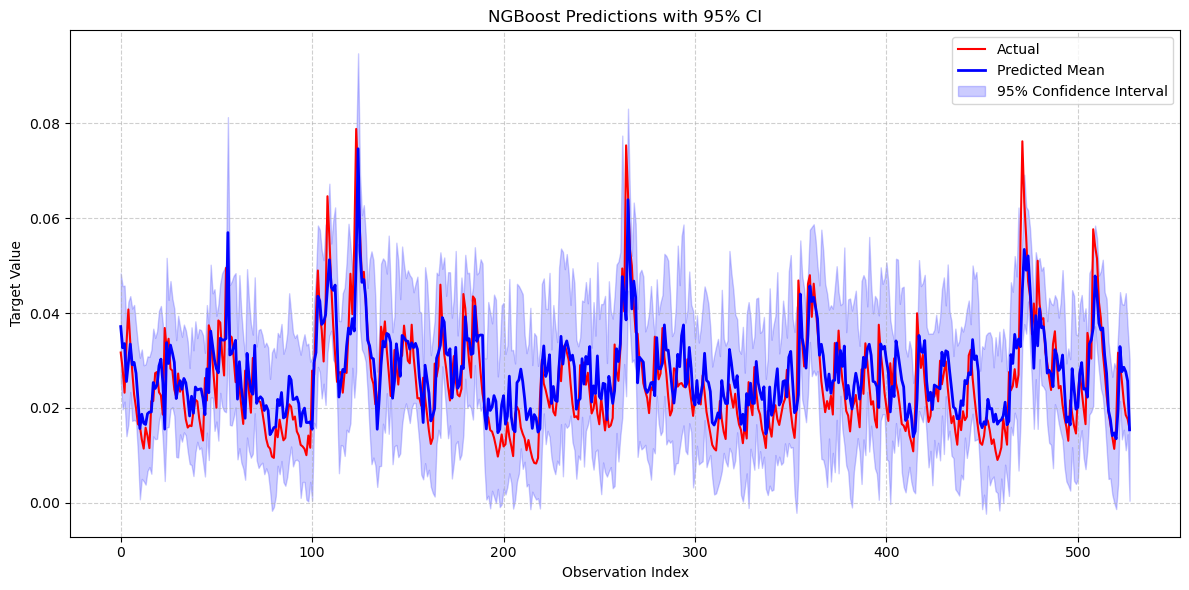

In [112]:
#show predictions w/ intervals
plot_ngboost_predictions(ngb_final, X_tt.drop(columns=['date']), y_tt, scaler_y=None)

**Note.** The variance scaling factor calibrated in the validation set was not applied to the test set as it resulted in over-coverage (100%), pointing to excessively conservative predictions intervals. As the unscaled NGBoost model already achieves near-nominal coverage, the raw uncertainty estimates are kept to preserve sharpness.

#### SAVING MODELS FOR DEPLOYMENT

NGboost is the top performing model, therefore it will be the only model saved.

In [ ]:
#save best XGboost
#xgb_artifact = {
  #  'model': xgb_final,
  #  'feature_names': X_train.drop(columns=['date']).columns.tolist()
#}
#joblib.dump(xgb_artifact, "forecast_Deployment_models/xgb_volatility_model.joblib")

In [113]:
#save best NGboost
ngb_artifact = {
    'model': ngb_final,
    'feature_names': X_train.drop(columns=['date']).columns.tolist(),
    "params": ngb_final.get_params()
}
joblib.dump(ngb_artifact, "forecast_Deployment_models/Forecast_ngb_volatility_model.joblib")

['forecast_Deployment_models/Forecast_ngb_volatility_model.joblib']

## MODEL'S LIMITS & POSSIBLE IMPROVEMENTS

In spite of the strong outcomes achieved, some room for improvement remains. 

First, including additional autocorrelated lag-structures in the feature set, like longer and regime-dependent volatility lags, could help in gathering persistent temporal dynamics.  
Second, expanding the dataset, either through a longer historical windows or higher-frequency observations, would open the possibility to explore more data-hungry models and improve robustness across market regimes.  
Third, adding more well-engineered features (macro-financial variables, market microstructure indicators or cross-asset signals) may enhane predictive power.
Finally, other deep-learning approaches may be investigated in the future. 

As a result, continuous model monitoring, periodic re-calibration and systematic re-testing are essential to ensure that the model remains the most suitable approach for the task.